<a href="https://colab.research.google.com/github/SiCHA06/submitting-work-SC663402/blob/main/sc663402_pandas_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

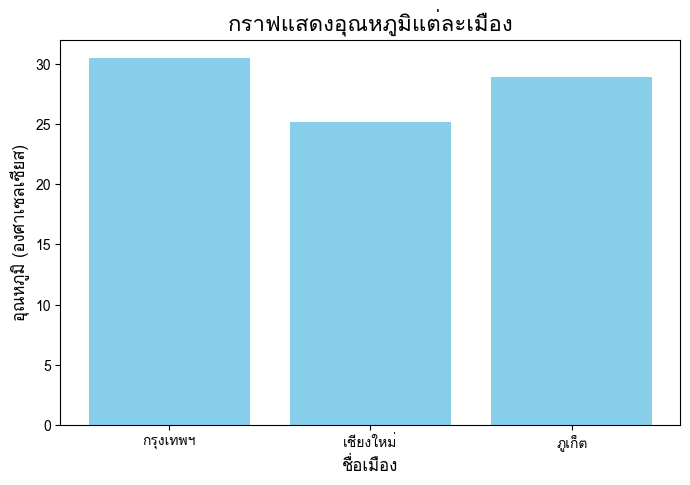

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [ ]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [ ]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [ ]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [ ]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [ ]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [ ]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [ ]:
# คำตอบข้อ 2.1
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

# 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
top_3_rain = rain_by_city.nlargest(3)
print("--- 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก ---")
print(top_3_rain)

# 2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
rain_proportion = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("\n--- 2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง ---")
print(rain_proportion.head()) # แสดงตัวอย่าง 5 บรรทัด

# 3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง
above_avg_count = (rain_by_city > rain_by_city.mean()).sum()
print("\n--- 3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง ---")
print(f"\n จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง: {above_avg_count} เมือง ")

--- 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก ---
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

--- 2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง ---
city
Auckland        4.22
Bangkok         8.21
Beijing         3.00
Berlin          3.21
Buenos Aires    3.65
Name: rainfall_mm, dtype: float64

--- 3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง ---

 จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง: 8 เมือง 


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [ ]:
# คำตอบข้อ 2.2
city_profile = df.groupby("city").agg(
    country=("country", "first"),
    region=("region", "first"),
    n_records=("temperature_c", "count"),
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum")
).reset_index()

print("\n--- ตาราง city_profile (ตัวอย่าง 5 แถวแรก) ---")
print(city_profile.head())


--- ตาราง city_profile (ตัวอย่าง 5 แถวแรก) ---
           city      country         region  n_records   avg_temp  total_rain
0      Auckland  New Zealand        Oceania         90  17.804444       351.9
1       Bangkok     Thailand           Asia         91  32.453846       685.6
2       Beijing        China           Asia         89  15.598876       250.1
3        Berlin      Germany         Europe         89  12.383146       268.4
4  Buenos Aires    Argentina  South America         89  19.171910       305.1


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [ ]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [ ]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [ ]:
# คำตอบข้อ 3.1
df_clean = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city"
)
print("--- ตรวจสอบชนิดข้อมูลและค่าว่าง (โจทย์ 3.1) ---")
df_clean.info()

--- ตรวจสอบชนิดข้อมูลและค่าว่าง (โจทย์ 3.1) ---
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [ ]:
# คำตอบข้อ 3.2
mem_original = df.memory_usage(deep=True).sum()
mem_clean = df_clean.memory_usage(deep=True).sum()
reduction_pct = (mem_original - mem_clean) / mem_original * 100
print(f"หน่วยความจำลดลง: {reduction_pct:.2f}%")

# ดูรายละเอียดหน่วยความจำแต่ละคอลัมน์เพื่อเปรียบเทียบ
print("\n--- หน่วยความจำตารางเดิม (bytes) ---")
print(df.memory_usage(deep=True).sort_values(ascending=False).head())

print("\n--- หน่วยความจำตารางใหม่ (bytes) ---")
print(df_clean.memory_usage(deep=True).sort_values(ascending=False))

หน่วยความจำลดลง: 87.24%

--- หน่วยความจำตารางเดิม (bytes) ---
date         122425
region       117631
city         116920
country      114937
record_id     16600
dtype: int64

--- หน่วยความจำตารางใหม่ (bytes) ---
date             16600
temperature_c    16600
rainfall_mm      16600
humidity_pct     16600
Index             3927
region            2590
dtype: int64


**อธิบาย ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด**

- **หน่วยความจำที่ลดลง:** ขนาดหน่วยความจำรวมของตารางลดลงถึง **87.24%**
- **คอลัมน์ที่มีผลต่อการลดลงมากที่สุด:** คอลัมน์ประเภทข้อความ (Object/String) และวันที่ เช่น date, region, city, และ country
- **เพราะเหตุใด:** ข้อมูลข้อความหรือ object ในแพนด้าเดิมจะใช้พื้นที่สูงมากในการเก็บพอยเตอร์ (Pointer) ชี้ไปยังข้อมูล เมื่อทำความสะอาดและแปลงชนิดข้อมูลให้เหมาะสมในโจทย์ 3.1 จึงช่วยประหยัดพื้นที่หน่วยความจำลงได้อย่างมหาศาล

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [ ]:
# คำตอบข้อ 3.3
import numpy as np
import pandas as pd

overall_max = -np.inf
overall_min = np.inf

# สร้าง Series เปล่าเพื่อเตรียมสะสมผลรวมและจำนวนนับ
city_sum = pd.Series(dtype=float)
city_count = pd.Series(dtype=int)

for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    # 1. หาค่าอุณหภูมิสูงสุดและต่ำสุดของ chunk เพื่อไปเปรียบเทียบกับค่ารวม
    chunk_max = chunk["temperature_c"].max()
    chunk_min = chunk["temperature_c"].min()

    if chunk_max > overall_max:
        overall_max = chunk_max
    if chunk_min < overall_min:
        overall_min = chunk_min

    # 2. สะสมผลรวมและจำนวนนับของอุณหภูมิตามเมือง
    chunk_city_sum = chunk.groupby("city")["temperature_c"].sum()
    chunk_city_count = chunk.groupby("city")["temperature_c"].count()

    # รวมค่าเข้ากับ Series หลัก
    city_sum = city_sum.add(chunk_city_sum, fill_value=0)
    city_count = city_count.add(chunk_city_count, fill_value=0)

# หาค่าเฉลี่ย
city_avg_temp = city_sum / city_count

print(f"--- 1. อุณหภูมิสูงสุดของทั้งไฟล์: {overall_max} C ---")
print(f"--- 1. อุณหภูมิต่ำสุดของทั้งไฟล์: {overall_min} C ---")
print("\n--- 2. อุณหภูมิเฉลี่ยรายเมือง (แสดงตัวอย่าง 5 เมืองแรก) ---")
print(city_avg_temp.head().round(2))


--- 1. อุณหภูมิสูงสุดของทั้งไฟล์: 999.0 C ---
--- 1. อุณหภูมิต่ำสุดของทั้งไฟล์: -88.0 C ---

--- 2. อุณหภูมิเฉลี่ยรายเมือง (แสดงตัวอย่าง 5 เมืองแรก) ---
city
Auckland        17.80
Bangkok         32.45
Beijing         15.60
Berlin          12.38
Buenos Aires    19.17
dtype: float64


**อธิบาย: เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง**

- **ทำไมนำค่าเฉลี่ยมาเฉลี่ยซ้ำจึงผิด:** เพราะขนาดข้อมูลแต่ละก้อนไม่เท่ากัน ทำให้เกิดความคลาดเคลื่อนจากการคิดน้ำหนักไม่เท่ากัน (ไม่ถ่วงน้ำหนัก)
- **ควรสะสมค่าใดแทน:** ต้องสะสม **"ผลรวม (Sum)"** และ **"จำนวนนับ (Count)"** ของแต่ละก้อนมารวมกัน แล้วค่อยนำมาหารกันในตอนท้าย จึงจะได้ค่าเฉลี่ยที่ถูกต้อง

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [ ]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().sum() / len(df) * 100).round(2),
    "n_unique": df.nunique(),
    "example_value": df.iloc[0]
}).sort_values(by="n_missing", ascending=False)

print("--- ตารางสรุปคุณภาพข้อมูลแต่ละคอลัมน์ ---")
print(summary)

--- ตารางสรุปคุณภาพข้อมูลแต่ละคอลัมน์ ---
                  dtype  n_missing  pct_missing  n_unique  example_value
humidity_pct    float64         82         3.95       544           72.6
rainfall_mm     float64         62         2.99       164            6.3
wind_speed_kmh  float64         41         1.98       278           15.9
pressure_hpa    float64         32         1.54       294         1005.4
temperature_c   float64         20         0.96       331           15.7
record_id         int64          0         0.00      2070            983
date             object          0         0.00        90     2025-03-24
region           object          0         0.00         6  North America
city             object          0         0.00        23       New York
country          object          0         0.00        28            USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [ ]:
# คำตอบข้อ 4.2
out_of_temp = (~df["temperature_c"].between(-60, 60)).sum()
out_of_humid = (~df["humidity_pct"].between(0, 100)).sum()
total_abnormal = ((~df["temperature_c"].between(-60, 60)) | (~df["humidity_pct"].between(0, 100))).sum()

print("\n--- จำนวนแถวที่พบค่าผิดปกติ ---")
print(f"อุณหภูมินอกช่วง: {out_of_temp} แถว")
print(f"ความชื้นนอกช่วง: {out_of_humid} แถว")
print(f"ผิดปกติอย่างน้อยหนึ่งคอลัมน์: {total_abnormal} แถว")


--- จำนวนแถวที่พบค่าผิดปกติ ---
อุณหภูมินอกช่วง: 25 แถว
ความชื้นนอกช่วง: 85 แถว
ผิดปกติอย่างน้อยหนึ่งคอลัมน์: 109 แถว


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [ ]:
# คำตอบข้อ 4.3
df["country_norm"] = df["country"].str.strip().str.title()
print("\n--- จำนวนประเทศหลังทำความสะอาดคำ ---")
print(f"จำนวนประเทศที่ไม่ซ้ำ: {df['country_norm'].nunique()}")


--- จำนวนประเทศหลังทำความสะอาดคำ ---
จำนวนประเทศที่ไม่ซ้ำ: 21


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 9)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [ ]:
# คำตอบข้อ 5.1
ans_5_1_1 = df.iloc[1:10:2, -3:]
print("--- 1. แถวตำแหน่งเลขคู่ 10 แถวแรก 3 คอลัมน์สุดท้าย ---")
print(ans_5_1_1)

ans_5_1_2 = df.iloc[-1:-6:-1]
print("\n--- 2. ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน ---")
print(ans_5_1_2)

mid_idx = len(df) // 2
ans_5_1_3 = df.iloc[mid_idx, -1]
print("\n--- 3. ค่าเดี่ยวกึ่งกลางตารางคอลัมน์สุดท้าย ---")
print(f"\n ค่าเดี่ยวกึ่งกลางตารางคอลัมน์สุดท้าย: {ans_5_1_3}")

--- 1. แถวตำแหน่งเลขคู่ 10 แถวแรก 3 คอลัมน์สุดท้าย ---
   wind_speed_kmh  pressure_hpa country_norm
1            20.5        1015.1        Japan
3            11.8        1000.1        India
5            16.4        1013.7  New Zealand
7            10.1        1015.2       Mexico
9            17.7        1003.5          Usa

--- 2. ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน ---
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

      temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
2074           11.1          65.8          6.3            20.4        1015.7   
2073            NaN          65.0          9.1             6.9     

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [ ]:
# คำตอบข้อ 5.2
# สร้าง DataFrame ที่มี index เป็นคู่ (region, city) และเรียงลำดับก่อน
multi = df.set_index(["region", "city"]).sort_index()

# 1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
ans_5_2_1 = multi.loc["Asia", ["date", "temperature_c"]]
print("--- 1. ข้อมูลภูมิภาค Asia (date, temperature_c) ---")
print(ans_5_2_1.head())

# 2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
# ใช้ slice(None) เพื่อละเว้นเงื่อนไขของ region (ดึงทุกภูมิภาคที่มีเมืองนี้)
ans_5_2_2 = multi.loc[(slice(None), ["Tokyo", "Bangkok"]), :]
print("\n--- 2. ข้อมูลเมือง Tokyo และ Bangkok ---")
print(ans_5_2_2.head())

# 3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B
mask_b = multi.index.get_level_values("city").str.startswith("B")
ans_5_2_3 = multi.loc[mask_b]
print("\n--- 3. ข้อมูลเมืองที่ขึ้นต้นด้วย B ---")
print(ans_5_2_3.head())

--- 1. ข้อมูลภูมิภาค Asia (date, temperature_c) ---
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0

--- 2. ข้อมูลเมือง Tokyo และ Bangkok ---
              record_id        date country  temperature_c  humidity_pct  \
region city                                                                
Asia   Tokyo        220  2025-02-09   Japan           18.3          60.6   
       Tokyo        260  2025-03-21   Japan           19.7          67.4   
       Tokyo        262  2025-03-23   Japan           17.7          60.2   
       Tokyo        203  2025-01-23   Japan           20.8          61.6   
       Tokyo        218  2025-02-07   Japan           19.5          68.2   

              rainfall_mm  wind_speed_kmh  pressure_hpa country_norm  
region city                                              

**อธิบาย: เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ**

การใช้ `.sort_index()` สำคัญมากสำหรับ MultiIndex เพราะกลไกการค้นหาแบบช่วง (Slicing) ของ pandas ทำงานโดยอิงจากการจัดเรียงตามตัวอักษร หาก index ไม่ถูกเรียง ลำดับการอ้างอิงจะผิดเพี้ยนและทำให้เกิดข้อผิดพลาด `UnsortedIndexError` ได้

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [ ]:
# คำตอบข้อ 5.3
# รูปแบบที่ 1: ต้องการแก้ไข df ต้นฉบับจริง (ใช้ .loc จัดการรวดเดียว)
df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

# รูปแบบที่ 2: ต้องการสร้างสำเนาแยกต่างหาก (ใช้ .copy() ให้ชัดเจน)
subset = df[df["city"] == "Bangkok"].copy()
subset["temperature_c"] = 0

**สรุปเป็นแนวปฏิบัติ (Guideline):**
หากต้องการแก้ไขข้อมูลต้นฉบับ ให้ใช้ `.loc[เงื่อนไข, คอลัมน์]` = ค่าใหม่ รวดเดียวเสมอ แต่ถ้าตั้งใจจะดึงข้อมูลออกไปดัดแปลงเล่นๆ โดยไม่ให้กระทบตารางหลัก ต้องใช้ `.copy()` ต่อท้ายตอนกรองข้อมูลทุกครั้ง เพื่อสร้างอ็อบเจกต์ใหม่ที่ตัดขาดจากต้นฉบับอย่างชัดเจน

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [ ]:
# คำตอบข้อ 6.1

# 1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
cond_1 = df.query("region == 'Asia' and rainfall_mm > 5 and wind_speed_kmh > 20")
print(f"--- 1. จำนวนแถวเอเชีย ฝน>5 ลม>20: {len(cond_1)} แถว ---")

# 2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
cond_2 = df[~df["city"].isin(["Bangkok", "Tokyo", "London"]) & df["humidity_pct"].between(40, 60)]
print(f"--- 2. จำนวนแถวที่ไม่ใช่ BKK, TYO, LON และความชื้น 40-60: {len(cond_2)} แถว ---")

# 3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
cond_3 = df[df.isna().sum(axis=1) >= 2]
print(f"--- 3. จำนวนแถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป: {len(cond_3)} แถว ---")

# 4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ .str.contains ร่วมกับ regular expression
cond_4 = df[df["city"].str.contains("New|San", regex=True, na=False)]
print(f"--- 4. จำนวนแถวที่ชื่อเมืองมีคำว่า New หรือ San: {len(cond_4)} แถว ---")

--- 1. จำนวนแถวเอเชีย ฝน>5 ลม>20: 54 แถว ---
--- 2. จำนวนแถวที่ไม่ใช่ BKK, TYO, LON และความชื้น 40-60: 470 แถว ---
--- 3. จำนวนแถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป: 8 แถว ---
--- 4. จำนวนแถวที่ชื่อเมืองมีคำว่า New หรือ San: 90 แถว ---


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 6.2
# 1. แทนค่าผิดปกติของอุณหภูมิด้วยค่าว่าง (NaN)
# (สมมติช่วงปกติคือ -60 ถึง 60 ตามโจทย์ข้อ 4.2)
df["temp_clean"] = df["temperature_c"].where(df["temperature_c"].between(-60, 60))

# 2. จำกัดค่าปริมาณฝนสูงสุดไว้ที่เปอร์เซ็นไทล์ที่ 99
cap_99 = df["rainfall_mm"].quantile(0.99)
df["rain_capped"] = df["rainfall_mm"].mask(df["rainfall_mm"] > cap_99, cap_99)

print(f"--- ค่าฝนสูงสุดเดิม: {df['rainfall_mm'].max()} | ค่าฝนที่ถูกจำกัด (cap): {df['rain_capped'].max()} ---")

--- ค่าฝนสูงสุดเดิม: 17.6 | ค่าฝนที่ถูกจำกัด (cap): 14.687999999999988 ---


**อธิบาย: แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป**

แนวทางนี้แตกต่างจากการลบแถวทิ้งตรงที่ จำนวนแถวของข้อมูลยังคงเท่าเดิม การลบแถวที่มีปัญหาทิ้งไปทั้งหมดจะทำให้เราสูญเสียข้อมูลที่ดีในคอลัมน์อื่นๆ ของแถวนั้นไปด้วย (เช่น อุณหภูมิผิดปกติ แต่ปริมาณฝนยังใช้ได้) การใช้ `.where`() หรือ `.mask()` ช่วยให้เราจัดการเฉพาะจุดที่ผิดปกติและยังนำคอลัมน์อื่นไปวิเคราะห์ต่อได้

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [ ]:
# คำตอบข้อ 6.3
# 1. คำนวณความเบี่ยงเบน (deviation) แบบสัมบูรณ์เทียบกับค่าเฉลี่ยของเมืองตนเอง
df["deviation"] = (df["temperature_c"] - df.groupby("city")["temperature_c"].transform("mean")).abs()

# 2. เรียงลำดับตามความเบี่ยงเบนจากมากไปน้อย แล้วเลือกแถวแรกของแต่ละเมือง
max_dev_by_city = df.sort_values(["city", "deviation"], ascending=[True, False]).groupby("city").head(1)

# 3. เลือกแสดงเฉพาะคอลัมน์ที่โจทย์กำหนด
result_6_3 = max_dev_by_city[["city", "date", "temperature_c", "deviation"]]

print("--- วันที่มีอุณหภูมิห่างจากค่าเฉลี่ยเมืองมากที่สุด (ตัวอย่าง 5 เมือง) ---")
print(result_6_3.head())

--- วันที่มีอุณหภูมิห่างจากค่าเฉลี่ยเมืองมากที่สุด (ตัวอย่าง 5 เมือง) ---
              city        date  temperature_c   deviation
1036      Auckland  2025-02-27           25.6    7.795556
67         Bangkok  2025-02-22            0.0    0.000000
1778       Beijing  2025-03-06           22.6    7.001124
1224        Berlin  2025-03-26           19.4    7.016854
1280  Buenos Aires  2025-01-19          -88.0  107.171910


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    0.0
2025-01-08    0.0
2025-01-15    0.0
2025-01-22    0.0
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [ ]:
# คำตอบข้อ 7.1
df = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week,
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5
)

print("--- ตัวอย่างคอลัมน์ใหม่ที่สร้างด้วย .assign() ---")
print(df[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head(3))

--- ตัวอย่างคอลัมน์ใหม่ที่สร้างด้วย .assign() ---
        date year_month  week_of_year  day_name  is_weekend
0 2025-03-24    2025-03            13    Monday       False
1 2025-02-09    2025-02             6    Sunday        True
2 2025-02-01    2025-02             5  Saturday        True


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [ ]:
# คำตอบข้อ 7.2

# 1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่
min_date = df["date"].min()
max_date = df["date"].max()
full_date_range = pd.date_range(start=min_date, end=max_date)
actual_dates = df["date"].unique()

missing_dates = full_date_range.difference(actual_dates)
total_days = (max_date - min_date).days + 1

print(f"--- 1. ข้อมูลครอบคลุมทั้งหมด: {total_days} วัน ---")
print(f"จำนวนวันที่ไม่มีข้อมูลเลย: {len(missing_dates)} วัน")
if len(missing_dates) > 0:
    print(f"ตัวอย่างวันที่หายไป: {missing_dates[0].date()}")

# 2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
temp_by_daytype = df.groupby(["region", "is_weekend"])["temperature_c"].mean().unstack()
temp_by_daytype.columns = ["วันธรรมดา", "วันหยุดสุดสัปดาห์"]
print("\n--- 2. อุณหภูมิเฉลี่ย (วันหยุด vs วันธรรมดา) ---")
print(temp_by_daytype.round(2))

# 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
monthly_rain = df.groupby(["city", "year_month"])["rainfall_mm"].sum().reset_index()
max_rain_month = monthly_rain.sort_values(["city", "rainfall_mm"], ascending=[True, False]).groupby("city").head(1)
print("\n--- 3. เดือนที่ฝนตกหนักที่สุดของแต่ละเมือง (แสดง 5 เมือง) ---")
print(max_rain_month.head())

--- 1. ข้อมูลครอบคลุมทั้งหมด: 90 วัน ---
จำนวนวันที่ไม่มีข้อมูลเลย: 0 วัน

--- 2. อุณหภูมิเฉลี่ย (วันหยุด vs วันธรรมดา) ---
               วันธรรมดา  วันหยุดสุดสัปดาห์
region                                     
Africa             27.94              23.88
Asia               22.98              21.12
Europe             15.82              11.95
North America      16.72              16.84
Oceania            18.94              19.40
South America      21.70              19.84

--- 3. เดือนที่ฝนตกหนักที่สุดของแต่ละเมือง (แสดง 5 เมือง) ---
            city year_month  rainfall_mm
2       Auckland    2025-03        150.0
4        Bangkok    2025-02        243.9
7        Beijing    2025-02         87.4
11        Berlin    2025-03        100.1
13  Buenos Aires    2025-02        121.2


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [ ]:
# คำตอบข้อ 7.3

# กรองข้อมูลเมือง Bangkok และตั้งค่า date เป็น index
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()

# สรุปข้อมูลเป็นราย 7 วัน
bkk_weekly = bkk.resample("7D").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum")
)

print("--- สรุปข้อมูลกรุงเทพฯ ราย 7 วัน ---")
print(bkk_weekly.head().round(2))

--- สรุปข้อมูลกรุงเทพฯ ราย 7 วัน ---
            avg_temp  total_rain
date                            
2025-01-01       0.0        65.7
2025-01-08       0.0        47.6
2025-01-15       0.0        58.7
2025-01-22       0.0        50.0
2025-01-29       0.0        55.4


**อธิบาย: `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น**

- `.resample()` ต่างจาก `groupby(df["date"].dt.month)` ตรงที่ `groupby(month)` จะจับกลุ่มข้อมูลที่มี "เลขเดือนเดียวกัน" มารวมกันเสมอ (เช่น เดือน 1 ของปี 2024 กับเดือน 1 ของปี 2025 จะถูกรวบเป็นก้อนเดียว)
- ในขณะที่ `.resample()` จะพิจารณาเส้นเวลาอย่างต่อเนื่อง (Time-series aware) และคงลำดับตามปฏิทินไว้
- กรณีที่จำเป็นต้องใช้ `.resample()` เท่านั้น คือเมื่อเราต้องการสรุปข้อมูลตามช่วงเวลาที่ไม่ได้ตรงกับหน่วยมาตรฐานตามปฏิทินเป๊ะๆ เช่น "ราย 7 วัน", "ราย 15 นาที" หรือกรณีที่มีวันที่ข้อมูลแหว่งหายไป `.resample()` สามารถสร้างช่วงเวลานั้นขึ้นมาและเติมค่าเป็น 0 หรือ NaN ให้เราได้อัตโนมัติ ซึ่ง groupby ธรรมดาทำไม่ได้

---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [ ]:
# คำตอบข้อ 8.1

# 1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
missing_counts = df.isna().sum()
max_missing_col = missing_counts.idxmax()
max_missing_pct = (missing_counts.max() / len(df)) * 100

print(f"--- 1. คอลัมน์ที่ค่าว่างมากสุด: {max_missing_col} ({max_missing_pct:.2f}%) ---")

# 2. ตารางแสดงสัดส่วนค่าว่างของ temperature_c จำแนกตามเมือง
missing_by_city = df.groupby("city")["temperature_c"].apply(lambda x: x.isna().mean()).reset_index(name="missing_prop")
print("\n--- 2. สัดส่วนค่าว่างรายเมือง (ตัวอย่าง 5 เมือง) ---")
print(missing_by_city.head())

# 3. หากลบทุกแถวที่มีค่าว่างด้วย dropna() จะเหลือข้อมูลเท่าใด และเมืองใดสูญเสียมากที่สุด
df_dropped = df.dropna()
rem_pct = (len(df_dropped) / len(df)) * 100

city_counts_orig = df.groupby("city").size()
city_counts_dropped = df_dropped.groupby("city").size()
city_loss = city_counts_orig - city_counts_dropped
worst_city = city_loss.idxmax()

print(f"\n--- 3. ข้อมูลคงเหลือหลัง dropna: {rem_pct:.2f}% ---")
print(f"เมืองที่สูญเสียข้อมูลมากที่สุด: {worst_city} (หายไป {city_loss.max()} แถว)")

--- 1. คอลัมน์ที่ค่าว่างมากสุด: humidity_pct (3.95%) ---

--- 2. สัดส่วนค่าว่างรายเมือง (ตัวอย่าง 5 เมือง) ---
           city  missing_prop
0      Auckland      0.000000
1       Bangkok      0.000000
2       Beijing      0.011111
3        Berlin      0.011111
4  Buenos Aires      0.011111

--- 3. ข้อมูลคงเหลือหลัง dropna: 88.72% ---
เมืองที่สูญเสียข้อมูลมากที่สุด: Auckland (หายไป 14 แถว)


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [ ]:
# คำตอบข้อ 8.2

# สร้าง DataFrame สำเนาเพื่อทดสอบการเติมค่า 3 รูปแบบ
df_fill = df.copy()

# วิธีที่ 1: เติมด้วยค่าเฉลี่ยรวมทั้งตาราง
df_fill["temp_global"] = df_fill["temperature_c"].fillna(df_fill["temperature_c"].mean())

# วิธีที่ 2: เติมด้วยค่าเฉลี่ยของเมืองตนเอง (ใช้ transform ตามตัวอย่าง)
df_fill["temp_city"] = df_fill["temperature_c"].fillna(
    df_fill.groupby("city")["temperature_c"].transform("mean")
)

# วิธีที่ 3: เติมด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน (ffill)
df_fill["temp_ffill"] = df_fill.sort_values(["city", "date"]).groupby("city")["temperature_c"].ffill()

# เปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน (std) รายเมือง
compare_stats = df_fill.groupby("city").agg(
    std_orig=("temperature_c", "std"),
    std_global=("temp_global", "std"),
    std_city=("temp_city", "std"),
    std_ffill=("temp_ffill", "std")
)
print("--- เปรียบเทียบส่วนเบี่ยงเบนมาตรฐาน (std) หลังเติมค่าว่าง ---")
print(compare_stats.head())

--- เปรียบเทียบส่วนเบี่ยงเบนมาตรฐาน (std) หลังเติมค่าว่าง ---
               std_orig  std_global   std_city  std_ffill
city                                                     
Auckland       2.799475    2.799475   2.799475   2.799475
Bangkok        0.000000    0.000000   0.000000   0.000000
Beijing        2.874792    2.903054   2.858596   2.868869
Berlin         2.595986    2.716171   2.581361   2.610393
Buenos Aires  11.817985   11.752118  11.751404  11.755036


**อธิบาย: วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ**

- วิธีที่เหมาะสมที่สุด: การเติมด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน (ffill) เนื่องจากข้อมูลอุตุนิยมวิทยาหรือสภาพอากาศมีความต่อเนื่องตามลำดับเวลา (Time Series)
- วิธีที่ทำให้ความแปรปรวนลดลงอย่างผิดธรรมชาติ: การเติมด้วยค่าเฉลี่ย (ไม่ว่าจะเป็นค่าเฉลี่ยรวมหรือค่าเฉลี่ยรายเมือง) เพราะการใส่ค่าคงเดิมซ้ำ ๆ ที่จุดกึ่งกลางจะไปลดการกระจายตัวของข้อมูล ทำให้ค่าส่วนเบี่ยงเบนมาตรฐาน (Std) หดตัวลงอย่างผิดธรรมชาติ

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [ ]:
# คำตอบข้อ 8.3

# 1. จำนวนคู่ (city, date) ที่ซ้ำกัน
# ใช้ subset เพื่อดูเฉพาะคีย์ ตามรูปแบบในตัวอย่าง
dup_pairs = df.duplicated(subset=["city", "date"]).sum()
print(f"--- 1. จำนวนคู่ (city, date) ที่ซ้ำกัน: {dup_pairs} แถว ---")

# 2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
exact_dups = df.duplicated().sum()
print(f"--- 2. ซ้ำทุกคอลัมน์: {exact_dups} แถว | ซ้ำเฉพาะคีย์: {dup_pairs} แถว ---")
# หาก exact_dups เท่ากับ dup_pairs แสดงว่าข้อมูลซ้ำกันทุกคอลัมน์ 100%
# หากน้อยกว่า แสดงว่ามีแถวที่คีย์ซ้ำกันแต่วัดค่าได้ไม่เท่ากัน (เช่น ขัดแย้งกันเอง)

# 3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน
# นโยบายที่เลือกใช้: เก็บข้อมูลแถวสุดท้ายไว้ (keep='last') หรือจะใช้ 'first' ก็ได้
df_cleaned = df.drop_duplicates(subset=["city", "date"], keep="last")

expected_rows = 23 * 90
actual_rows = len(df_cleaned)

print(f"\n--- 3. จำนวนแถวหลังขจัดข้อมูลซ้ำ: {actual_rows} แถว ---")
if actual_rows == expected_rows:
    print(">> การตรวจสอบผ่าน: เหลือข้อมูลตรงตาม 23 เมือง x 90 วัน พอดี")
else:
    print(f">> พบความผิดปกติ: จำนวนแถวที่ได้ ({actual_rows}) ไม่เท่ากับเป้าหมาย ({expected_rows})")

--- 1. จำนวนคู่ (city, date) ที่ซ้ำกัน: 5 แถว ---
--- 2. ซ้ำทุกคอลัมน์: 5 แถว | ซ้ำเฉพาะคีย์: 5 แถว ---

--- 3. จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070 แถว ---
>> การตรวจสอบผ่าน: เหลือข้อมูลตรงตาม 23 เมือง x 90 วัน พอดี


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 19)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland      17.8       351.9      26.0      90
Bangkok        0.0       680.0      29.8      90
Beijing       15.6       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [ ]:
# คำตอบข้อ 9.1
summary_91 = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum()),
    pct_missing_temp=("temperature_c", lambda x: x.isna().mean())
)

print("--- ตารางสรุปรายเมือง (แสดง 5 เมืองแรก) ---")
print(summary_91.head().round(3))

--- ตารางสรุปรายเมือง (แสดง 5 เมืองแรก) ---
              avg_temp  median_temp  std_temp  total_rain  heavy_rain_days  \
city                                                                         
Auckland        17.804        17.55     2.799       351.9                6   
Bangkok          0.000         0.00     0.000       680.0               23   
Beijing         15.599        15.50     2.875       250.1                2   
Berlin          12.383        12.30     2.596       268.4                6   
Buenos Aires    19.172        20.70    11.818       305.1                9   

              pct_missing_temp  
city                            
Auckland                 0.000  
Bangkok                  0.000  
Beijing                  0.011  
Berlin                   0.011  
Buenos Aires             0.011  


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [ ]:
# คำตอบข้อ 9.2

# 1. สร้างตารางสรุปและจัดรูปตารางด้วย reset_index()
summary_92 = df.groupby(["region", "month"])["temperature_c"].mean().reset_index()

print("--- ตารางอุณหภูมิเฉลี่ยตามภูมิภาคและเดือน (ตัวอย่าง) ---")
print(summary_92.head())

# 2. หาคู่ภูมิภาคและเดือนที่มีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด
max_temp_idx = summary_92["temperature_c"].idxmax()
min_temp_idx = summary_92["temperature_c"].idxmin()

highest = summary_92.loc[max_temp_idx]
lowest = summary_92.loc[min_temp_idx]

print("\n--- คู่ภูมิภาคและเดือนที่อุณหภูมิเฉลี่ย สูงสุด ---")
print(f"ภูมิภาค: {highest['region']}, เดือน: {int(highest['month'])}, อุณหภูมิ: {highest['temperature_c']:.2f} C")

print("\n--- คู่ภูมิภาคและเดือนที่อุณหภูมิเฉลี่ย ต่ำสุด ---")
print(f"ภูมิภาค: {lowest['region']}, เดือน: {int(lowest['month'])}, อุณหภูมิ: {lowest['temperature_c']:.2f} C")

--- ตารางอุณหภูมิเฉลี่ยตามภูมิภาคและเดือน (ตัวอย่าง) ---
   region  month  temperature_c
0  Africa      1      22.641667
1  Africa      2      32.741441
2  Africa      3      25.414754
3    Asia      1      18.993011
4    Asia      2      21.283234

--- คู่ภูมิภาคและเดือนที่อุณหภูมิเฉลี่ย สูงสุด ---
ภูมิภาค: Africa, เดือน: 2, อุณหภูมิ: 32.74 C

--- คู่ภูมิภาคและเดือนที่อุณหภูมิเฉลี่ย ต่ำสุด ---
ภูมิภาค: Europe, เดือน: 1, อุณหภูมิ: 10.40 C


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [ ]:
# คำตอบข้อ 9.3 (โค้ดแสดงหลักฐาน)
check_days = df.groupby("city").agg(
    n_days_count=("temperature_c", "count"),
    n_days_size=("temperature_c", "size")
)

# กรองดูเฉพาะเมืองที่ผลลัพธ์ของ count และ size ไม่เท่ากัน
diff_cases = check_days[check_days["n_days_count"] != check_days["n_days_size"]]
print("--- เปรียบเทียบเมืองที่ count และ size ให้ผลต่างกัน ---")
print(diff_cases.head())

--- เปรียบเทียบเมืองที่ count และ size ให้ผลต่างกัน ---
              n_days_count  n_days_size
city                                   
Beijing                 89           90
Berlin                  89           90
Buenos Aires            89           90
Cairo                   88           90
Cape Town               89           90


**อธิบาย: ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร**

- ผลลัพธ์จาก `count` และ `size` มีความแตกต่างกันsize: จะนับ "จำนวนแถวทั้งหมด" ในกลุ่มนั้นเสมอ ไม่ว่าข้างในจะเป็นค่าว่าง `(NaN)` หรือไม่ก็ตาม
- `count`: จะนับเฉพาะแถวที่มี "ข้อมูลที่ไม่ใช่ค่าว่าง (Non-null values)" ในคอลัมน์ที่เราระบุเท่านั้น

**ผลเสียหากเลือกใช้ผิด:**   
หากเราต้องการรายงาน "จำนวนวันที่ลงบันทึกข้อมูลทั้งหมด" ของแต่ละเมือง แต่ดันไปใช้ `count` ในคอลัมน์ที่มีค่าว่าง (เช่น `temperature_c`) รายงานจะแสดงจำนวนวันน้อยกว่าความเป็นจริง ทำให้ผู้บริหารหรือผู้อ่านรายงานเข้าใจผิดว่าเมืองนั้นมีวันในปฏิทินไม่ครบ หรือบันทึกข้อมูลตกหล่นทั้งๆ ที่จริงๆ แค่เซนเซอร์อุณหภูมิอาจจะเสียในวันนั้นครับ

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    1960.000
mean        0.000
std         0.995
min        -9.069
25%        -0.517
50%        -0.079
75%         0.523
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [ ]:
# คำตอบข้อ 10.1

# 1. สร้าง 3 คอลัมน์ใหม่โดยใช้ transform
# - rain_share: ปริมาณฝนวันนั้น / ฝนรวมของเมืองนั้น
df["rain_share"] = df["rainfall_mm"] / df.groupby("city")["rainfall_mm"].transform("sum")

df["temp_z"] = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())

monthly_avg_by_city = df.groupby(["city", "month"])["temperature_c"].transform("mean")
df["city_rank_month"] = df.assign(m_avg=monthly_avg_by_city).groupby("city")["m_avg"].rank(method="dense", ascending=False)

# 2. ตรวจสอบว่าผลรวมของ rain_share ในแต่ละเมืองเท่ากับ 1 หรือไม่
sum_rain_share = df.groupby("city")["rain_share"].sum()
is_all_one = np.allclose(sum_rain_share, 1.0)

print(f"--- ผลรวม rain_share แต่ละเมืองเท่ากับ 1 ทุกเมืองใช่หรือไม่?: {is_all_one} ---")
print("\nตัวอย่างข้อมูลผลรวม (5 เมืองแรก):")
print(sum_rain_share.head())

--- ผลรวม rain_share แต่ละเมืองเท่ากับ 1 ทุกเมืองใช่หรือไม่?: True ---

ตัวอย่างข้อมูลผลรวม (5 เมืองแรก):
city
Auckland        1.0
Bangkok         1.0
Beijing         1.0
Berlin          1.0
Buenos Aires    1.0
Name: rain_share, dtype: float64


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [ ]:
# คำตอบข้อ 10.2

# 1. ใช้ groupby().filter()
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)

# หาเมืองที่ถูกคัดออก
all_cities = set(df["city"].unique())
kept_cities = set(big_cities["city"].unique())
dropped_cities = all_cities - kept_cities

print(f"--- 1. เมืองที่ถูกคัดออก (มีข้อมูลไม่ถึง 88 วัน): {dropped_cities} ---")

# 2. วิธีทางเลือกที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ filter()
# 2.1 หาจำนวนวันที่ข้อมูลไม่ว่างของแต่ละเมือง
valid_counts = df.groupby("city")["temperature_c"].count()
# 2.2 คัดเฉพาะเมืองที่ผ่านเกณฑ์
cities_to_keep = valid_counts[valid_counts >= 88].index
# 2.3 กรองตารางหลักด้วย .isin()
big_cities_alt = df[df["city"].isin(cities_to_keep)]

# เปรียบเทียบความกระชับ
print(f"จำนวนเมืองก่อนคัด: {df['city'].nunique()} หลังคัดด้วย filter: {big_cities['city'].nunique()}, หลังคัดด้วยวิธีอื่น: {big_cities_alt['city'].nunique()}")

--- 1. เมืองที่ถูกคัดออก (มีข้อมูลไม่ถึง 88 วัน): {'Lagos'} ---
จำนวนเมืองก่อนคัด: 23 หลังคัดด้วย filter: 22, หลังคัดด้วยวิธีอื่น: 22


**เปรียบเทียบความกระชับของทั้งสองวิธี**

วิธีใช้ `.filter()` มักจะสั้น กระชับ และเขียนจบในบรรทัดเดียวได้สะดวกกว่า (เหมือนในตัวอย่าง) แต่ถ้าเงื่อนไขมีความซับซ้อนมาก การแยกหาคีย์ที่ผ่านเกณฑ์ก่อนแล้วค่อยเอามาคัดออกด้วย `.isin()` (แบบวิธีที่ 2) อาจจะอ่านเข้าใจง่ายกว่าและจัดการ Performance ได้ดีกว่าเมื่อข้อมูลมีขนาดใหญ่มาก ๆ ครับ

### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [ ]:
# คำตอบข้อ 10.3

# ดึงคอลัมน์ที่ต้องการ แล้วเรียงลำดับตาม temp_z จากมากไปน้อย เอา 5 แถวแรก
top_5_extreme_days = df[["city", "date", "temperature_c", "temp_z"]].sort_values("temp_z", ascending=False).head(5)

print("--- 5 วันที่มีค่าอุณหภูมิผิดปกติ (เมื่อเทียบกับเมืองตนเอง) สูงสุด ---")
print(top_5_extreme_days)

--- 5 วันที่มีค่าอุณหภูมิผิดปกติ (เมื่อเทียบกับเมืองตนเอง) สูงสุด ---
           city       date  temperature_c    temp_z
78    Cape Town 2025-02-10          999.0  9.324775
712       Paris 2025-03-28          999.0  9.324085
1855  Singapore 2025-03-11          999.0  9.308847
747      London 2025-02-09           23.4  3.283188
1834   New York 2025-03-16           24.5  2.991056


**อธิบาย: เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง**

เหตุผลที่การหาค่าผิดปกติโดยเทียบภายในกลุ่ม (เมืองตนเอง) จึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง เป็นเพราะ แต่ละเมืองตั้งอยู่ในสภาพภูมิอากาศและละติจูดที่ต่างกัน อุณหภูมิ 35 องศาเซลเซียส อาจเป็นเรื่องปกติสำหรับกรุงเทพมหานคร (Bangkok) แต่เป็นความร้อนที่ผิดปกติอย่างรุนแรง (Heatwave) หากเกิดขึ้นที่ลอนดอน (London) การใช้ Z-score ที่อิงจากค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานของเมืองนั้น ๆ จึงสะท้อนความ "ผิดปกติที่แท้จริง" ของพื้นที่นั้นได้ดีกว่าการเอื้อมไปเทียบกับเมืองอื่นครับ

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [ ]:
# คำตอบข้อ 11.1
import time

# วิธีที่ 1: การเรียงลำดับแล้วใช้ groupby().head()
start_time = time.time()
top3_method1 = df.sort_values(["region", "temperature_c"], ascending=[True, False]).groupby("region").head(3)
time_method1 = time.time() - start_time

# วิธีที่ 2: ใช้ groupby().apply() ร่วมกับ nlargest()
start_time = time.time()
# จำเป็นต้อง drop level หรือ reset_index เพื่อให้รูปแบบตารางเหมือนวิธีแรก
top3_method2 = df.groupby("region").apply(lambda x: x.nlargest(3, "temperature_c")).reset_index(drop=True)
time_method2 = time.time() - start_time

print(f"--- วิธีที่ 1 (sort_values + head) ใช้เวลา: {time_method1:.5f} วินาที ---")
print(f"--- วิธีที่ 2 (apply + nlargest) ใช้เวลา: {time_method2:.5f} วินาที ---")

# แสดงผลลัพธ์ (เลือกมาแสดงเฉพาะบางคอลัมน์เพื่อความกะทัดรัด)
print("\n--- ผลลัพธ์ 3 อันดับแรกของแต่ละภูมิภาค (จากวิธีที่ 1) ---")
print(top3_method1[["region", "city", "date", "temperature_c"]])

--- วิธีที่ 1 (sort_values + head) ใช้เวลา: 0.00886 วินาที ---
--- วิธีที่ 2 (apply + nlargest) ใช้เวลา: 0.04836 วินาที ---

--- ผลลัพธ์ 3 อันดับแรกของแต่ละภูมิภาค (จากวิธีที่ 1) ---
             region         city       date  temperature_c
78           Africa    Cape Town 2025-02-10          999.0
1065         Africa        Lagos 2025-03-22           37.2
1152         Africa        Lagos 2025-03-31           35.8
1855           Asia    Singapore 2025-03-11          999.0
1767           Asia    Singapore 2025-02-23           39.2
2066           Asia   Chiang Mai 2025-03-28           37.3
712          Europe        Paris 2025-03-28          999.0
747          Europe       London 2025-02-09           23.4
1352         Europe        Paris 2025-03-11           20.6
181   North America  Los Angeles 2025-02-27           26.5
1735  North America  Mexico City 2025-02-24           26.5
439   North America  Los Angeles 2025-02-10           26.3
1036        Oceania     Auckland 2025-02-27       

/tmp/ipykernel_788/1188659542.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_method2 = df.groupby("region").apply(lambda x: x.nlargest(3, "temperature_c")).reset_index(drop=True)


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [ ]:
# คำตอบข้อ 11.2

# สร้างคอลัมน์ rank ทั้ง 3 แบบ (เรียงจากมากไปน้อย เลยต้องใช้ ascending=False)
# หมายเหตุ: ตามตัวอย่าง ต้องใช้ transform กับ rank เมื่อต้องการสร้างคอลัมน์กลับเข้าไปในตารางเดิม
df["rank_avg"] = df.groupby("city")["rainfall_mm"].rank(method="average", ascending=False)
df["rank_min"] = df.groupby("city")["rainfall_mm"].rank(method="min", ascending=False)
df["rank_dense"] = df.groupby("city")["rainfall_mm"].rank(method="dense", ascending=False)

# ลองดึงข้อมูลของเมืองสักเมืองมาดู (เช่น ฝนตก 0 mm จำนวนมาก)
sample_rank = df[df["city"] == "Bangkok"].sort_values("rainfall_mm")[["date", "rainfall_mm", "rank_avg", "rank_min", "rank_dense"]]

print("--- เปรียบเทียบผลการ rank เมื่อมีค่าฝนเท่ากัน (ตัวอย่างเมือง Bangkok) ---")
print(sample_rank.head(10)) # ดูพวกที่ฝนตก 0 mm

--- เปรียบเทียบผลการ rank เมื่อมีค่าฝนเท่ากัน (ตัวอย่างเมือง Bangkok) ---
           date  rainfall_mm  rank_avg  rank_min  rank_dense
67   2025-02-22          0.0      86.0      85.0        65.0
677  2025-03-18          0.0      86.0      85.0        65.0
792  2025-03-30          0.0      86.0      85.0        65.0
1059 2025-01-08          0.2      84.0      84.0        64.0
501  2025-01-29          1.6      83.0      83.0        63.0
1112 2025-03-24          1.9      82.0      82.0        62.0
263  2025-02-23          2.3      81.0      81.0        61.0
236  2025-03-11          2.4      80.0      80.0        60.0
1498 2025-03-29          2.5      79.0      79.0        59.0
201  2025-03-20          2.7      77.5      77.0        58.0


**อธิบาย ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก**

สมมติว่ามีวันที่ฝนไม่ตกเลย (0 mm) จำนวน 50 วัน และเป็นค่าที่น้อยที่สุด (อันดับรั้งท้าย)

`method="average"`: จะเอาอันดับที่ควรจะเป็นของทั้ง 50 วันนั้นมาบวกกันแล้วหารเฉลี่ย (เช่น อันดับที่ 41 ถึง 90 เฉลี่ยได้ 65.5) ทุกวันที่ฝนไม่ตกจะได้อันดับ 65.5 เท่ากันหมด

`method="min"`: จะให้อันดับ "ที่ดีที่สุด" ในกลุ่มที่เท่ากัน (เช่น อันดับที่ 41 ถึง 90 ทุกวันจะได้อันดับ 41) เหมาะกับการทำ Leaderboard ว่า "คุณได้อันดับที่ 41 ร่วม"

`method="dense"`: จะไม่กระโดดข้ามตัวเลขอันดับเลย ถ้าค่าก่อนหน้านี้คืออันดับ 4 กลุ่มที่ฝนตก 0 mm ทั้งหมดนี้จะได้ "อันดับ 5" เหมือนกันหมด

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [ ]:
# คำตอบข้อ 11.3

# 1. คำนวณอุณหภูมิเฉลี่ยและจำนวนวันที่มีข้อมูลของแต่ละเมือง
city_stats = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    n_days=("temperature_c", "count") # ใช้ countเพื่อนับแถวที่ไม่ใช่ NaN หรือ size ถ้านับทุกแถว
).reset_index()

# 2. สร้างคอลัมน์ Flag ว่าข้อมูลครบ 90 วันหรือไม่ (True=ครบ, False=ไม่ครบ)
city_stats["is_complete"] = city_stats["n_days"] == 90

# 3. เรียงลำดับโดยใช้หลายเงื่อนไข (sort_values รับ list ของคอลัมน์ได้)
# - เงื่อนไขแรก: is_complete (เรียงจาก True (1) ไป False (0) จึงต้องใช้ ascending=False)
# - เงื่อนไขสอง: avg_temp (เรียงจากมากไปน้อย ascending=False)
sorted_cities = city_stats.sort_values(["is_complete", "avg_temp"], ascending=[False, False])

print("--- ลำดับเมืองตามอุณหภูมิ (เมืองที่ข้อมูลไม่ครบ 90 วันอยู่ท้ายสุด) ---")
print(sorted_cities)

--- ลำดับเมืองตามอุณหภูมิ (เมืองที่ข้อมูลไม่ครบ 90 วันอยู่ท้ายสุด) ---
            city   avg_temp  n_days  is_complete
19     Singapore  40.083333      90         True
14        Mumbai  30.872222      90         True
7     Chiang Mai  29.650000      90         True
9           Lima  21.490000      90         True
20        Sydney  20.347778      90         True
12   Mexico City  19.187778      90         True
0       Auckland  17.804444      90         True
16      New York  15.476667      90         True
1        Bangkok   0.000000      90         True
6      Cape Town  30.162921      89        False
8          Lagos  29.494253      87        False
5          Cairo  26.070455      88        False
17         Paris  25.811236      89        False
18     Sao Paulo  22.841573      89        False
15       Nairobi  21.429213      89        False
11   Los Angeles  20.657303      89        False
4   Buenos Aires  19.171910      89        False
21         Tokyo  18.414773      88        Fals

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
เย็น        564
ร้อน        446
ร้อนจัด      13
Name: count, dtype: int64
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(24.2, 999.0]      512
(19.1, 24.2]       510
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [ ]:
# คำตอบข้อ 12.1

# 1. เมืองที่มีจำนวนวันฝนตกหนัก (> 10 mm) สูงสุด 5 อันดับแรก
heavy_rain_count = df[df["rainfall_mm"] > 10].groupby("city").size()
top5_count = heavy_rain_count.nlargest(5)
print("--- 1. Top 5 เมืองที่มีจำนวนวันฝนตกหนักมากที่สุด ---")
print(top5_count)

# 2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
# คำนวณจำนวนวันที่บันทึกข้อมูลฝนได้จริงของแต่ละเมือง
total_valid_days = df["rainfall_mm"].notna().groupby(df["city"]).sum()
heavy_rain_prop = (heavy_rain_count / total_valid_days).dropna()
top5_prop = heavy_rain_prop.nlargest(5)
print("\n--- 2. Top 5 เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด ---")
print(top5_prop.round(3))

--- 1. Top 5 เมืองที่มีจำนวนวันฝนตกหนักมากที่สุด ---
city
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9
dtype: int64

--- 2. Top 5 เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด ---
city
Singapore     0.489
Bangkok       0.264
Lagos         0.250
Sao Paulo     0.125
Chiang Mai    0.106
dtype: float64


**อธิบาย ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง**

ผลลัพธ์ของจำนวนนับและสัดส่วนอาจแตกต่างกันหากแต่ละเมืองมี "จำนวนวันที่เก็บข้อมูลได้" ไม่เท่ากัน ตัวชี้วัดที่เหมาะสมกว่าในการเปรียบเทียบระหว่างเมืองคือ สัดส่วน (Proportion) เพราะเป็นการปรับฐานข้อมูลให้เท่าเทียมกัน (Normalize) ทำให้เมืองที่ถูกเก็บข้อมูลมาน้อยไม่เสียเปรียบเมืองที่ถูกเก็บข้อมูลมาหลายวัน

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [ ]:
# คำตอบข้อ 12.2

# สร้างช่วงอุณหภูมิตามที่กำหนดเอง
temp_bins = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100], labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])

# 1. จำนวนนับ (Count)
ct_count = pd.crosstab(df["region"], temp_bins)
print("--- 1. จำนวนนับ (Count) ---")
print(ct_count.head())

# 2. สัดส่วนตามแถว (Row Proportion) - ผลรวมแต่ละภูมิภาคแนวนอน = 1
ct_row = pd.crosstab(df["region"], temp_bins, normalize="index")
print("\n--- 2. สัดส่วนตามแถว (normalize='index') ---")
print(ct_row.head().round(2))

# 3. สัดส่วนตามคอลัมน์ (Column Proportion) - ผลรวมแต่ละช่วงอุณหภูมิแนวตั้ง = 1
ct_col = pd.crosstab(df["region"], temp_bins, normalize="columns")
print("\n--- 3. สัดส่วนตามคอลัมน์ (normalize='columns') ---")
print(ct_col.head().round(2))

--- 1. จำนวนนับ (Count) ---
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0

--- 2. สัดส่วนตามแถว (normalize='index') ---
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00

--- 3. สัดส่วนตามคอลัมน์ (normalize='columns') ---
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.01    0.20  0.32     0.23
Asia           0.24    0.14  0.57     0.77
Europe         0.49    0.08  0.00     0.00
North America  0.22    0.21  0.03     0.00
Oceania       

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 12.3

# แบ่งอุณหภูมิออกเป็น 4 กลุ่มด้วย cut และ qcut
temp_cut_4 = pd.cut(df["temperature_c"], bins=4)
temp_qcut_4 = pd.qcut(df["temperature_c"], q=4)

print("--- จำนวนสมาชิกที่แบ่งด้วย pd.cut() ---")
print(temp_cut_4.value_counts().sort_index())

print("\n--- จำนวนสมาชิกที่แบ่งด้วย pd.qcut() ---")
print(temp_qcut_4.value_counts().sort_index())

--- จำนวนสมาชิกที่แบ่งด้วย pd.cut() ---
temperature_c
(-89.087, 183.75]    2047
(183.75, 455.5]         0
(455.5, 727.25]         0
(727.25, 999.0]         3
Name: count, dtype: int64

--- จำนวนสมาชิกที่แบ่งด้วย pd.qcut() ---
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(19.1, 24.2]       510
(24.2, 999.0]      512
Name: count, dtype: int64


**อธิบาย: เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด**

เหตุที่จำนวนสมาชิกแตกต่างกัน:
- `pd.cut()` แบ่งกลุ่มตาม "ความกว้างของช่วงค่า (Value)" ให้เท่าๆ กัน ดังนั้นหากข้อมูลกระจุกตัวอยู่ที่ค่าใดค่าหนึ่ง กลุ่มนั้นก็จะมีสมาชิกเยอะมาก และกลุ่มที่เป็นค่าสุดโต่งจะมีสมาชิกน้อย
- `pd.qcut()` แบ่งกลุ่มตาม "จำนวนสมาชิก (Quantile)" ดังนั้นอัลกอริทึมจะปรับขยายช่วงค่าอุณหภูมิให้กว้างหรือแคบโดยอัตโนมัติ เพื่อบีบให้แต่ละกลุ่มมีจำนวนแถวใกล้เคียงกันที่สุด

การเลือกใช้:
- ใช้ `cut` เมื่อสนใจ "เกณฑ์ตัวเลขที่ตายตัว" เช่น แบ่งเกณฑ์อุณหภูมิทางกายภาพ (ร้อน, หนาว)
- ใช้ `qcut` เมื่อสนใจ "การจัดอันดับเชิงเปรียบเทียบ" เช่น ต้องการจัดกลุ่มประเทศเป็น Top 25% ที่ร้อนที่สุด หรือแบ่งกลุ่มลูกค้าตามกำลังซื้อออกเป็น 4 เทียร์ (Quartile) ที่มีจำนวนคนเท่ากัน  

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     18.99
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia        0.00
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia        0.00
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [ ]:
# คำตอบข้อ 13.1

# สร้าง pivot_table แถว=city, คอลัมน์=month, ค่า=rainfall_mm (sum) พร้อมยอดรวม (margins)
pivot_rain = df.pivot_table(
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    margins=True,
    margins_name="รวม"
)

# หาเมืองที่มีฝนรวมสูงสุด (ตัดแถว 'รวม' ออกก่อนหา max)
max_rain_city = pivot_rain.drop("รวม")["รวม"].idxmax()
max_rain_val = pivot_rain.drop("รวม")["รวม"].max()

print("--- ตารางปริมาณฝนรายเมือง-รายเดือน (pivot_table) ---")
print(pivot_rain.head())
print(f"\n>> เมืองที่มีปริมาณฝนรวมทั้ง 3 เดือนสูงสุดคือ: {max_rain_city} ({max_rain_val:.2f} mm)")

--- ตารางปริมาณฝนรายเมือง-รายเดือน (pivot_table) ---
month             1      2      3    รวม
city                                    
Auckland      106.2   95.7  150.0  351.9
Bangkok       231.6  243.9  204.5  680.0
Beijing        77.6   87.4   85.1  250.1
Berlin         98.4   69.9  100.1  268.4
Buenos Aires   93.5  121.2   90.4  305.1

>> เมืองที่มีปริมาณฝนรวมทั้ง 3 เดือนสูงสุดคือ: Singapore (870.40 mm)


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 13.3

# เอา margins ออกก่อนเพื่อให้ได้ตารางกว้างแบบปกติ แล้ว reset_index ให้ city เป็นคอลัมน์
wide_df = pivot_rain.drop("รวม").drop(columns="รวม").reset_index()

# แปลงเป็นตารางยาว (long format)
long_df = wide_df.melt(
    id_vars="city",
    var_name="month",
    value_name="rainfall_mm"
)

print("--- ตารางรูปยาว (Long Format) ---")
print(long_df.head())
print(f"จำนวนแถวรูปยาว: {len(long_df)}") # 23 เมือง * 3 เดือน = 69 แถว

--- ตารางรูปยาว (Long Format) ---
           city month  rainfall_mm
0      Auckland     1        106.2
1       Bangkok     1        231.6
2       Beijing     1         77.6
3        Berlin     1         98.4
4  Buenos Aires     1         93.5
จำนวนแถวรูปยาว: 69


**อธิบาย: ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด**

- ตารางรูปยาว (Long Format): เหมาะสำหรับการ "จัดเก็บในฐานข้อมูล" หรือส่งเข้าโมเดล/ไลบรารีวาดกราฟ (เช่น seaborn, Tableau) เพราะโครงสร้างมีความเป็นระเบียบ แต่ละแถวคือ 1 Record ทำให้คอมพิวเตอร์ประมวลผลและทำ filter/groupby ได้ง่าย

- ตารางรูปกว้าง (Wide/Pivot Format): เหมาะสำหรับการ "นำเสนอให้มนุษย์อ่าน" เช่น ทำรายงานบน Excel เพราะตาคนเราสามารถมองกวาดเปรียบเทียบแนวโน้ม (เช่น ดูฝนจากเดือน 1 ไปเดือน 3 ในแนวนอน) ได้ง่ายกว่าตารางยาวครับ

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [ ]:
# คำตอบข้อ 13.3


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [ ]:
# คำตอบข้อ 13.4

# 1. สร้างตาราง index คู่ (region, city) และคอลัมน์คู่ (month, metric)
grouped = df.groupby(["region", "city", "month"])[["temperature_c", "rainfall_mm"]].mean()
wide_multi = grouped.unstack("month") # ดัน month ขึ้นไปเป็นคอลัมน์ชั้นที่ 2
print("--- ตารางก่อน Swaplevel ---")
print(wide_multi.head(2))

# 2. ใช้ swaplevel เพื่อสลับชั้นของคอลัมน์ เอา month ขึ้นมาเป็นชั้นนอกสุด แล้ว sort_index คอลัมน์
# axis=1 หมายถึงการทำกับคอลัมน์
wide_swapped = wide_multi.swaplevel(0, 1, axis=1).sort_index(axis=1)

# 3. เลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในทวีป Asia
# ใช้ slice(None) ข้ามเงื่อนไข city และใช้การดึงคอลัมน์เดือน 2 ตรงๆ
result_134 = wide_swapped.loc[("Asia", slice(None)), 2]

print("\n--- ผลลัพธ์: ภูมิภาค Asia เฉพาะเดือนที่ 2 ---")
print(result_134.head())

--- ตารางก่อน Swaplevel ---
                 temperature_c                       rainfall_mm            \
month                        1          2          3           1         2   
region city                                                                  
Africa Cairo         24.746667  26.218519  27.222581    1.000000  1.755556   
       Cape Town     18.136667  53.617857  20.616129    3.170968  2.307407   

                            
month                    3  
region city                 
Africa Cairo      1.483871  
       Cape Town  2.713793  

--- ผลลัพธ์: ภูมิภาค Asia เฉพาะเดือนที่ 2 ---
                   rainfall_mm  temperature_c
region city                                  
Asia   Bangkok        9.033333       0.000000
       Beijing        3.121429      15.996296
       Chiang Mai     5.103704      29.828571
       Mumbai         6.611538      31.810714
       Singapore      9.867857      30.982143


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 27) -> (2070, 29)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 28)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [ ]:
# คำตอบข้อ 14.1

# 1. & 2. รวมตารางและจัดการคอลัมน์ซ้ำ
# สังเกตว่าใน df และ city_info อาจมีคอลัมน์ชื่อซ้ำกัน (เช่น 'country')
# การระบุ suffixes=(False, False) หรือดรอปคอลัมน์ซ้ำทิ้งก่อนรวม จะช่วยเลี่ยงปัญหา _x, _y
city_info_clean = city_info.drop(columns=["country", "region"], errors="ignore")

# ทำการ merge แบบ left join ตามลำดับ
merged_df = (df
             .merge(city_info_clean, on="city", how="left")
             .merge(region_info, on="region", how="left"))

print(f"--- 1. รูปร่างตารางเดิม: {df.shape} | หลังรวม: {merged_df.shape} ---")
# คำอธิบาย: จำนวนแถวควรเท่าเดิม (2070 แถว) เพราะเป็นการใช้ how='left'
# โดยที่ตารางฝั่งขวา (city_info, region_info) มีคีย์ที่ไม่ซ้ำกันเลย (One-to-One/Many-to-One)

print("--- 2. ตรวจสอบคอลัมน์ที่มี _x หรือ _y ---")
print([c for c in merged_df.columns if "_x" in c or "_y" in c])

# 3. อุณหภูมิเฉลี่ยจำแนกตาม timezone และ continent_code
print("\n--- 3. อุณหภูมิเฉลี่ยตาม Timezone ---")
print(merged_df.groupby("timezone")["temperature_c"].mean().round(2).head())

print("\n--- 3. อุณหภูมิเฉลี่ยตาม Continent Code ---")
print(merged_df.groupby("continent_code")["temperature_c"].mean().round(2))

--- 1. รูปร่างตารางเดิม: (2070, 27) | หลังรวม: (2070, 31) ---
--- 2. ตรวจสอบคอลัมน์ที่มี _x หรือ _y ---
['week_of_year']

--- 3. อุณหภูมิเฉลี่ยตาม Timezone ---
timezone
UTC+0     13.49
UTC+1     22.51
UTC+10    20.35
UTC+12    17.80
UTC+2     28.13
Name: temperature_c, dtype: float64

--- 3. อุณหภูมิเฉลี่ยตาม Continent Code ---
continent_code
AF     26.78
AS     22.46
EU     14.72
NAM    16.75
OC     19.08
SAM    21.17
Name: temperature_c, dtype: float64


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [ ]:
# คำตอบข้อ 14.2

# จำลองการเพิ่มแถวซ้ำ (เช่น ข้อมูลกรุงเทพฯ ซ้ำ 2 แถว)
city_info_dup = pd.concat([city_info, city_info[city_info["city"] == "Bangkok"]], ignore_index=True)

# รวมตารางด้วยข้อมูลที่จำลองขึ้น
merged_dup = df.merge(city_info_dup, on="city", how="left")

# 1. จำนวนแถวที่เพิ่มขึ้น
rows_added = len(merged_dup) - len(df)
print(f"--- 1. จำนวนแถวที่เพิ่มขึ้น: {rows_added} แถว ---")

# 2. ปริมาณฝนรวมที่เปลี่ยนแปลง
rain_orig = df["rainfall_mm"].sum()
rain_dup = merged_dup["rainfall_mm"].sum()
rain_diff_pct = (rain_dup - rain_orig) / rain_orig * 100
print(f"--- 2. ปริมาณฝนรวมเพิ่มขึ้น: {rain_diff_pct:.2f}% ---")

# 3. ผลของการใช้ validate
try:
    df.merge(city_info_dup, on="city", how="left", validate="many_to_one")
except Exception as e:
    print(f"\n--- 3. ผลของการใช้ validate: เกิด Error แจ้งเตือนดังนี้ ---")
    print(e)

--- 1. จำนวนแถวที่เพิ่มขึ้น: 90 แถว ---
--- 2. ปริมาณฝนรวมเพิ่มขึ้น: 8.16% ---

--- 3. ผลของการใช้ validate: เกิด Error แจ้งเตือนดังนี้ ---
Merge keys are not unique in right dataset; not a many-to-one merge


**อธิบาย: เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด**

หากตารางฝั่งขวา (Master Data) มีคีย์ซ้ำกัน การทำ Left Join จะทำให้เกิดการ "คูณแบบคาร์ทีเซียน (Cartesian Product)" ทำให้จำนวนแถวผลลัพธ์งอกขึ้นมาโดยที่โปรแกรม ไม่แจ้ง Error ใดๆ ข้อผิดพลาดนี้อันตรายมาก เพราะมันจะทำงานผ่านไปเงียบๆ แต่ส่งผลให้ตัวเลขสรุปผล (เช่น ผลรวมปริมาณฝน) เบิ้ลขึ้นไปตามจำนวนแถวที่งอกมา ทำให้รายงานทางสถิติผิดเพี้ยนไปทั้งหมด การใช้ `validate="many_to_one"` จึงเป็นแนวปฏิบัติที่ดีเพื่อป้องกันปัญหานี้ครับ

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [ ]:
# คำตอบข้อ 14.3

# จำลองคีย์สกปรก
df_dirty = df.copy()
df_dirty.loc[df_dirty["city"] == "Bangkok", "city"] = " Bangkok " # เติมช่องว่าง

# รวมตารางพร้อมเปิด indicator
merged_dirty = df_dirty.merge(city_info, on="city", how="left", indicator=True)

# ตรวจสอบการจับคู่
failed_match = merged_dirty[merged_dirty["_merge"] == "left_only"]
print(f"--- จำนวนแถวที่จับคู่ไม่ได้ (left_only): {len(failed_match)} แถว ---")
print("ตัวอย่างเมืองที่หลุด:")
print(failed_match["city"].unique())

# --- ขั้นตอนการทำความสะอาดคีย์ก่อนรวม ---
print("\n--- วิธีทำความสะอาดคีย์ ---")
df_dirty["city_clean"] = df_dirty["city"].str.strip().str.title()
city_info["city_clean"] = city_info["city"].str.strip().str.title()
# จากนั้นค่อย merge ด้วยออนคีย์ 'city_clean'

--- จำนวนแถวที่จับคู่ไม่ได้ (left_only): 90 แถว ---
ตัวอย่างเมืองที่หลุด:
[' Bangkok ']

--- วิธีทำความสะอาดคีย์ ---


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [ ]:
# คำตอบข้อ 14.4

# กำหนด index ให้เป็นคีย์ที่ต้องการเชื่อม
left_table = df.set_index("city")
right_table1 = city_info_clean.set_index("city")

# ทำการ join (โดยดีฟอลต์ join จะเป็นการเชื่อมผ่าน index และทำแบบ left join)
joined_df = left_table.join(right_table1)

# นำไป join กับตารางที่ 3 ต่อ โดยสลับ index เป็น region
joined_all = joined_df.reset_index().set_index("region").join(region_info.set_index("region"))

print("--- รูปร่างตารางจากการใช้ .join() ---")
print(joined_all.shape)

--- รูปร่างตารางจากการใช้ .join() ---
(2070, 30)


**ความสะดวกของ `.join()`:** สะดวกมากเมื่อเราตั้งคอลัมน์ที่ต้องการเชื่อมเป็น Index ไว้เรียบร้อยแล้ว หรือเมื่อต้องการนำ DataFrame เล็กๆ หลายๆ อัน (ที่มี Index ตรงกัน) มาต่อกันรวดเดียวในคำสั่งเดียว (เช่น `df1.join([df2, df3])`)

**ข้อจำกัด:** มันบังคับให้ต้องเชื่อมผ่าน Index เป็นหลักเป็นหลักเท่านั้น (แม้จะมีพารามิเตอร์ `on` แต่ก็สับสนกว่า merge) หากต้องเชื่อมด้วยคอลัมน์หลายคอลัมน์พร้อมกัน (เช่น คีย์คู่) หรือตารางยังไม่ได้เซ็ต Index การใช้ `.merge(on=...)` จะอ่านง่ายและตรงไปตรงมากว่าครับ

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 27)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 27)
(1357, 26)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 15.1

# 1. แบ่ง df ออกเป็น 3 ส่วนตามเดือน
m1 = df[df["month"] == 1]
m2 = df[df["month"] == 2]
m3 = df[df["month"] == 3]

# 2. ต่อตารางกลับเข้าด้วยกันโดยกำหนด ignore_index=True
df_rebuilt = pd.concat([m1, m2, m3], ignore_index=True)

# 3. ตรวจสอบจำนวนแถวและ index
is_length_match = len(df) == len(df_rebuilt)
is_index_unique = df_rebuilt.index.is_unique

print(f"--- จำนวนแถวเท่าเดิมหรือไม่: {is_length_match} ---")
print(f"--- Index ไม่ซ้ำกันใช่หรือไม่: {is_index_unique} ---")

--- จำนวนแถวเท่าเดิมหรือไม่: True ---
--- Index ไม่ซ้ำกันใช่หรือไม่: True ---


**อธิบาย: หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป**

หากเราไม่กำหนด `ignore_index=True` ผลลัพธ์จากการใช้ `concat` จะเก็บค่า Index เดิมของตารางย่อยเอาไว้ ทำให้ตารางใหม่มีเลข Index ที่ซ้ำกัน (เช่น มี index เลข 0 อยู่ 3 แถวจากแต่ละเดือน) เมื่อเราใช้คำสั่ง `.loc[0]` ในขั้นถัดไป แทนที่จะได้ข้อมูลกลับมาแค่ 1 แถว โปรแกรมจะคืนค่ากลับมา 3 แถวพร้อมกัน ซึ่งจะทำให้การคำนวณหรือการอ้างอิงข้อมูลผิดพลาดได้ครับ

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 15.2

# สร้าง DataFrame ใหม่ที่คอลัมน์ไม่ครบ (เอาแค่ 3 คอลัมน์แรก) และเพิ่มคอลัมน์ใหม่
df_extra = df.iloc[:5, :3].copy()
df_extra["new_sensor_data"] = 99.9

# เปรียบเทียบ join="outer" และ join="inner"
concat_outer = pd.concat([df.head(2), df_extra], join="outer", ignore_index=True)
concat_inner = pd.concat([df.head(2), df_extra], join="inner", ignore_index=True)

print("--- รูปร่างตารางเดิม:", df.head(2).shape, "และตารางใหม่:", df_extra.shape, "---")
print("--- ผลลัพธ์ join='outer' (เก็บทุกคอลัมน์):", concat_outer.shape, "---")
print(concat_outer.head(3))

print("\n--- ผลลัพธ์ join='inner' (เก็บเฉพาะคอลัมน์ที่ตรงกัน):", concat_inner.shape, "---")
print(concat_inner.head(3))

--- รูปร่างตารางเดิม: (2, 27) และตารางใหม่: (5, 4) ---
--- ผลลัพธ์ join='outer' (เก็บทุกคอลัมน์): (7, 28) ---
   record_id       date      city country         region  temperature_c  \
0        983 2025-03-24  New York     USA  North America           15.7   
1        220 2025-02-09     Tokyo   Japan           Asia           18.3   
2        983 2025-03-24  New York     NaN            NaN            NaN   

   humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  ... month  \
0          72.6          6.3            15.9        1005.4  ...   3.0   
1          60.6          0.0            20.5        1015.1  ...   2.0   
2           NaN          NaN             NaN           NaN  ...   NaN   

   city_avg_temp  temp_diff  rain_share    temp_z  city_rank_month rank_avg  \
0      15.476667   0.223333    0.019987  0.074031              1.0     19.0   
1      18.414773  -0.114773    0.000000 -0.045581              2.0     82.5   
2            NaN        NaN         NaN       NaN          

**อธิบาย: ควรเลือกใช้แบบใดในสถานการณ์ใด**

- ใช้ `join="outer"` (ค่าเริ่มต้น): เมื่อต้องการ "เก็บข้อมูลไว้ให้ได้มากที่สุด" แม้บางคอลัมน์จะโหว่ (เป็น `NaN`) ก็ตาม เช่น การนำข้อมูลสภาพอากาศจากเซนเซอร์รุ่นเก่ามาต่อกับเซนเซอร์รุ่นใหม่ที่มีฟังก์ชันวัดฝุ่น PM2.5 เพิ่มเข้ามา
- ใช้ `join="inner"`: เมื่อต้องการ "บังคับโครงสร้างให้เป็นมาตรฐานเดียวกันอย่างเข้มงวด" คอลัมน์ใดที่ตารางอื่นไม่มีจะถูกตัดทิ้งทันที เหมาะกับการเตรียมข้อมูลเข้าโมเดล Machine Learning ที่ต้องการจำนวน Features (คอลัมน์) คงที่เสมอครับ

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [ ]:
# คำตอบข้อ 15.3

# ใช้ keys ร่วมกับ concat เพื่อสร้าง Index หลายระดับที่ระบุว่าก้อนนี้มาจากไหน
stacked_df = pd.concat([m1, m2, m3], keys=["Jan", "Feb", "Mar"], names=["batch_month"])

print("--- ตรวจสอบแหล่งที่มาของข้อมูล (keys) ---")
print(stacked_df.index.get_level_values("batch_month").unique().tolist())

# วิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย .loc[]
retrieved_feb = stacked_df.loc["Feb"]

print("\n--- ผลลัพธ์จากการดึงเฉพาะก้อน 'Feb' กลับคืนมา ---")
print(retrieved_feb.head(3))

--- ตรวจสอบแหล่งที่มาของข้อมูล (keys) ---
['Jan', 'Feb', 'Mar']

--- ผลลัพธ์จากการดึงเฉพาะก้อน 'Feb' กลับคืนมา ---
   record_id       date         city       country         region  \
1        220 2025-02-09        Tokyo         Japan           Asia   
2       1022 2025-02-01  Los Angeles           USA  North America   
4       1834 2025-02-03    Cape Town  South Africa         Africa   

   temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
1           18.3          60.6          0.0            20.5        1015.1   
2           20.6          46.8          1.2             8.6        1013.5   
4           19.1          55.0          0.0            16.6        1015.1   

   ... is_weekend  month  city_avg_temp  temp_diff rain_share    temp_z  \
1  ...       True      2      18.414773  -0.114773    0.00000 -0.045581   
2  ...       True      2      20.657303  -0.057303    0.00708 -0.019002   
4  ...      False      2      30.162921 -11.062921    0.00000 -0.106477   

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

**อธิบาย: เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้**

- `concat` (การต่อ/แปะตาราง): ทำงานอิงตาม "ตำแหน่งหรือโครงสร้าง (Index/Columns)" เป็นหลัก เหมือนการเอาเอกสารมาวางซ้อนกัน (ต่อแกน Y) หรือวางต่อกันด้านข้าง (ต่อแกน X) โดยไม่สนใจค่าที่อยู่ข้างใน
>- สถานการณ์ที่ใช้ `merge` แทนไม่ได้: การนำไฟล์ Log ธุรกรรมการเงินรายวันของเดือนที่ 1, 2, และ 3 มาต่อกันให้กลายเป็นไฟล์ประวัติรายไตรมาส (การเพิ่มจำนวนแถว/Records)

- `merge` (การรวมตาราง): ทำงานอิงตาม "ความสัมพันธ์ของค่าข้อมูล (Key Values)" เป็นหลัก เหมือน VLOOKUP ใน Excel หรือ JOIN ใน SQL โดยจะมองหาค่าที่ตรงกันในคอลัมน์ที่กำหนดเพื่อจับคู่ข้อมูลเข้าด้วยกัน
>- สถานการณ์ที่ใช้ `concat` แทนไม่ได้: การมีตารางรายชื่อลูกค้า (`customer_id`, `name`) และต้องการดึงข้อมูลยอดซื้อจากอีกตาราง (`customer_id`, `total_spent`) มาแปะให้ตรงกับชื่อลูกค้าคนนั้นๆ (การจับคู่ข้อมูล) `concat` ทำไม่ได้เพราะลำดับรายชื่อลูกค้าในสองตารางอาจเรียงสลับกันครับ

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
เย็น            556
ร้อน            451
ไม่มีข้อมูล      20
ร้อนจัด          17
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1748
ฝนหนัก       144
ร้อนชื้น     120
ลมแรง         58
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              20.85               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [ ]:
# คำตอบข้อ 16.1
import numpy as np
import time

# สร้างเงื่อนไข 3 คอลัมน์ 4 กลุ่ม
cond_1 = (df["temperature_c"] > 30) & (df["humidity_pct"] > 70) & (df["rainfall_mm"] > 5)
cond_2 = (df["temperature_c"] < 15) & (df["wind_speed_kmh"] > 25) & (df["rainfall_mm"] == 0)
cond_3 = (df["rainfall_mm"] > 50) & (df["wind_speed_kmh"] > 10)
choices = ["ร้อนชื้นและฝนตก", "หนาวลมแรง", "พายุฝน"]

# วิธีที่ 1: df.apply(..., axis=1)
def classify_weather(row):
    if row["temperature_c"] > 30 and row["humidity_pct"] > 70 and row["rainfall_mm"] > 5:
        return "ร้อนชื้นและฝนตก"
    elif row["temperature_c"] < 15 and row["wind_speed_kmh"] > 25 and row["rainfall_mm"] == 0:
        return "หนาวลมแรง"
    elif row["rainfall_mm"] > 50 and row["wind_speed_kmh"] > 10:
        return "พายุฝน"
    return "ปกติ"

start_time = time.perf_counter()
res_apply = df.apply(classify_weather, axis=1)
time_apply = time.perf_counter() - start_time

# วิธีที่ 2: np.select
start_time = time.perf_counter()
res_select = np.select([cond_1, cond_2, cond_3], choices, default="ปกติ")
time_select = time.perf_counter() - start_time

# วิธีที่ 3: np.where ซ้อนกัน
start_time = time.perf_counter()
res_where = np.where(cond_1, choices[0],
              np.where(cond_2, choices[1],
                np.where(cond_3, choices[2], "ปกติ")))
time_where = time.perf_counter() - start_time

# ตรวจสอบความถูกต้องและเปรียบเทียบเวลา
is_match = (res_apply == res_select).all() and (res_select == res_where).all()
fastest = min(time_apply, time_select, time_where)
slowest = max(time_apply, time_select, time_where)

print(f"--- 1. ผลลัพธ์ทั้งสามวิธีตรงกันทุกแถวหรือไม่: {is_match} ---")
print(f"เวลา apply: {time_apply:.5f} วิ | select: {time_select:.5f} วิ | where: {time_where:.5f} วิ")
print(f"วิธีที่เร็วที่สุด เร็วกว่าวิธีที่ช้าที่สุด {slowest / fastest:.2f} เท่า")

--- 1. ผลลัพธ์ทั้งสามวิธีตรงกันทุกแถวหรือไม่: True ---
เวลา apply: 0.03126 วิ | select: 0.00028 วิ | where: 0.00034 วิ
วิธีที่เร็วที่สุด เร็วกว่าวิธีที่ช้าที่สุด 113.25 เท่า


**รายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า**

การใช้ `np.select` และ `np.where` เป็นการทำงานแบบ `Vectorized` ซึ่งประมวลผลข้อมูลทั้งอาร์เรย์ในระดับภาษา C ทำให้รวดเร็วกว่าการใช้ apply(axis=1) ที่ต้องวนซ้ำประมวลผลทีละแถวในระดับภาษา Python เสมอ

### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [ ]:
# คำตอบข้อ 16.2
# สร้าง dictionary สำหรับแมปชื่อภูมิภาค (จงใจละเว้นบางทวีปเพื่อจำลองค่าว่าง)
region_dict = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}

# สร้างคอลัมน์ด้วย .map()
df["region_code"] = df["region"].map(region_dict)

print("--- 2. ตรวจสอบค่าว่างจากการใช้ .map() ---")
print(f"จำนวนแถวที่ไม่มีรหัสกำกับ (เป็น NaN): {df['region_code'].isna().sum()} แถว")

# วิธีจัดการค่าที่ไม่มีใน dict
df["region_code_clean"] = df["region_code"].fillna("OTHER")
print("จำนวนแถวที่เป็น NaN หลังจัดการด้วย fillna():", df["region_code_clean"].isna().sum())

--- 2. ตรวจสอบค่าว่างจากการใช้ .map() ---
จำนวนแถวที่ไม่มีรหัสกำกับ (เป็น NaN): 810 แถว
จำนวนแถวที่เป็น NaN หลังจัดการด้วย fillna(): 0


**อธิบาย: `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict**

**ความแตกต่าง:**`.apply()` บน Series ใช้สำหรับส่งข้อมูลแต่ละค่าเข้าไปประมวลผลใน "ฟังก์ชัน" ในขณะที่ `.map()` นิยมใช้สำหรับเทียบค่าและแปลงร่างข้อมูลจาก "พจนานุกรม (Dictionary)" หรือฟังก์ชันก็ได้

**วิธีจัดการค่าที่ไม่มีใน dict:** หากค่าในข้อมูลไม่มีคีย์ตรงกับใน Dictionary ฟังก์ชัน .map() จะแปลงค่านั้นให้กลายเป็นค่าว่าง (`NaN`) ทันที วิธีจัดการที่เหมาะสมคือการใช้ `.fillna`("ค่าเริ่มต้น") ต่อท้ายเพื่อเติมเต็มช่องว่างเหล่านั้น

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [ ]:
# คำตอบข้อ 16.3

# สูตรอย่างง่าย: อุณหภูมิ + (ความชื้น * 0.1)
def heat_index(temp, humidity):
    return temp + (humidity * 0.1)

# วิธีที่ 1: เรียกผ่าน apply(..., axis=1)
start_time = time.perf_counter()
df["hi_apply"] = df.apply(lambda row: heat_index(row["temperature_c"], row["humidity_pct"]), axis=1)
time_apply_hi = time.perf_counter() - start_time

# วิธีที่ 2: ส่ง Series เข้าฟังก์ชันโดยตรง
start_time = time.perf_counter()
df["hi_vectorized"] = heat_index(df["temperature_c"], df["humidity_pct"])
time_vec_hi = time.perf_counter() - start_time

print(f"--- 3. เปรียบเทียบความเร็วการสร้าง Heat Index ---")
print(f"apply(axis=1): {time_apply_hi:.5f} วิ | Series Direct: {time_vec_hi:.5f} วิ")
print("ตัวอย่างผลลัพธ์:")
print(df[["temperature_c", "humidity_pct", "hi_vectorized"]].head(3))

--- 3. เปรียบเทียบความเร็วการสร้าง Heat Index ---
apply(axis=1): 0.05269 วิ | Series Direct: 0.00080 วิ
ตัวอย่างผลลัพธ์:
   temperature_c  humidity_pct  hi_vectorized
0           15.7          72.6          22.96
1           18.3          60.6          24.36
2           20.6          46.8          25.28


**อธิบาย: เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้**

**เหตุใดวิธีที่สองจึงทำงานได้:** แม้เราจะเขียนฟังก์ชัน `heat_index` ขึ้นมาเพื่อรับค่าตัวเลขเดี่ยว ๆ แต่เมื่อเราส่ง `Series` เข้าไป ตัวดำเนินการทางคณิตศาสตร์ (เช่น +, *) ใน Python ถูกออกแบบมาให้รองรับการคำนวณแบบกระจายตัว (Element-wise) บน `Series` ได้อัตโนมัติ ทำให้มันจับคู่คำนวณแถวต่อแถวให้ทันทีโดยไม่ต้องวนซ้ำ

**เงื่อนไขที่ทำให้วิธีที่สองใช้ไม่ได้:** หากภายในฟังก์ชัน `heat_index` มีการใช้คำสั่งเงื่อนไขพื้นฐานของ Python เช่น `if temp > 30:` การส่ง `Series` เข้าไปจะทำให้เกิด Error ทันที (ValueError: The truth value of a Series is ambiguous) เพราะ if ของ Python ประเมินค่าตรรกศาสตร์ของข้อมูลทั้งคอลัมน์พร้อมกันไม่ได้   

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

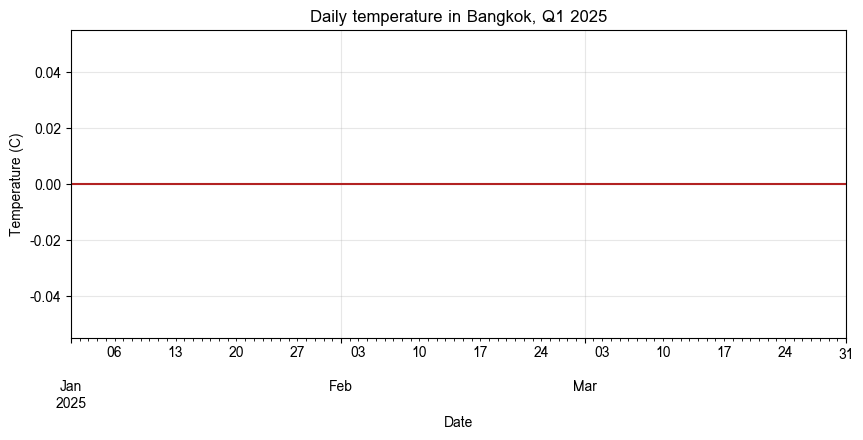

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

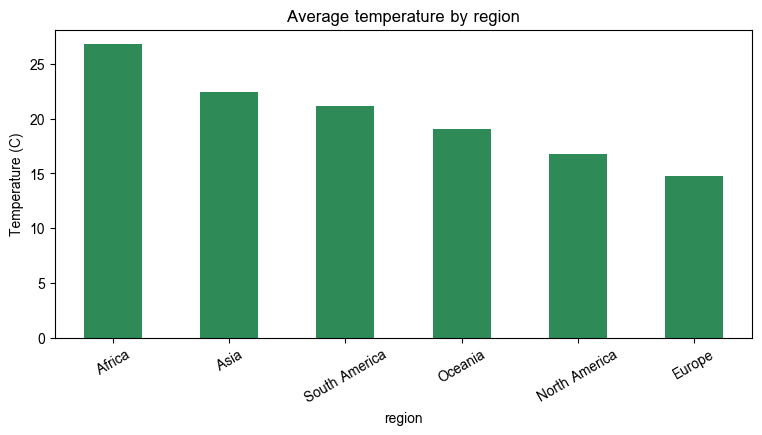

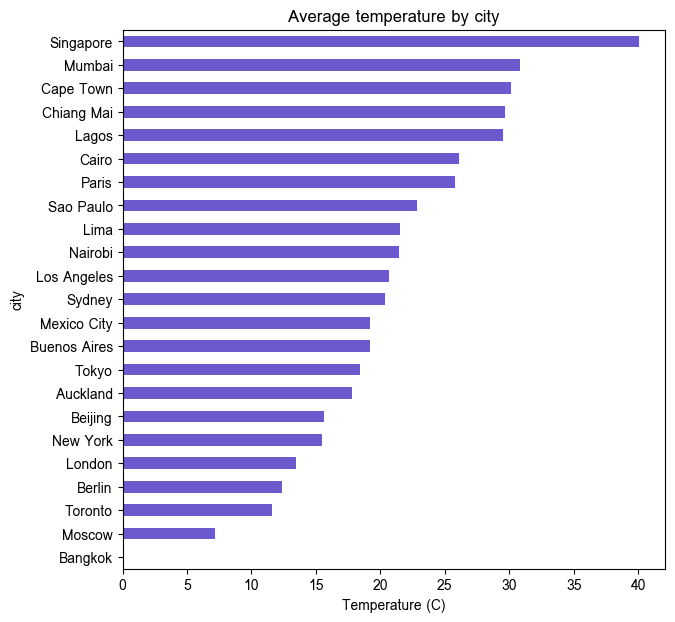

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

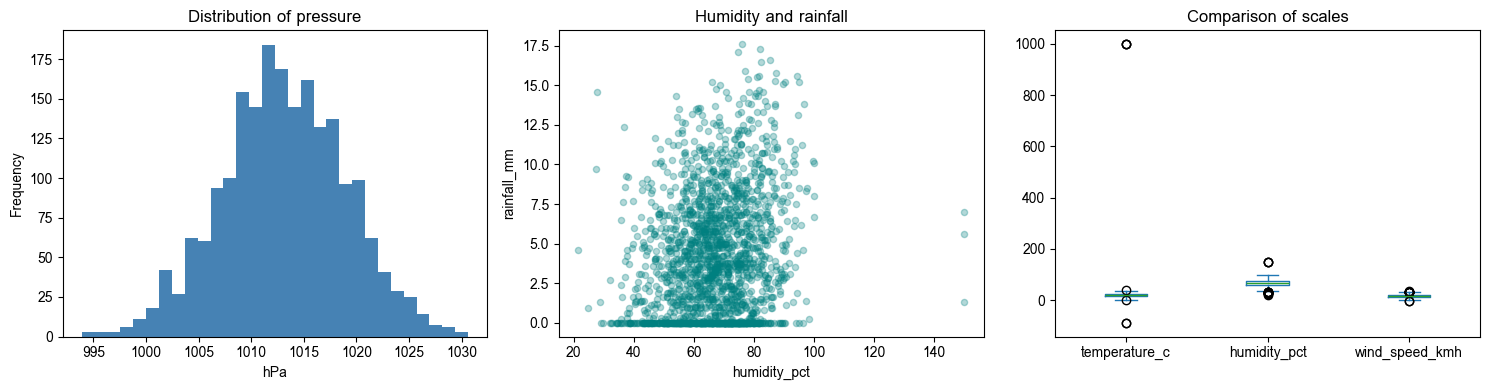

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

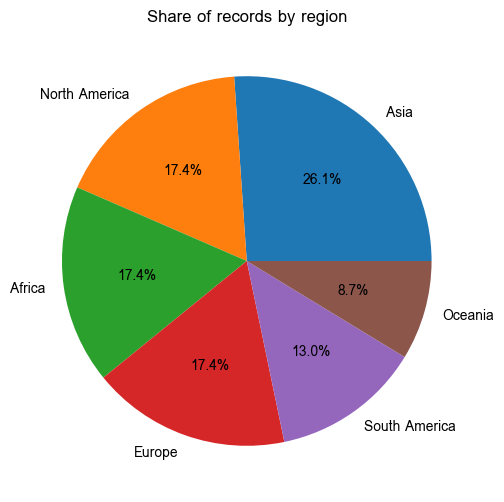

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

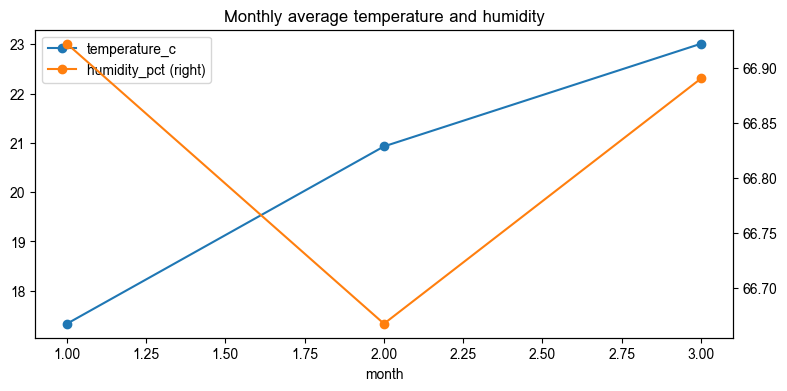

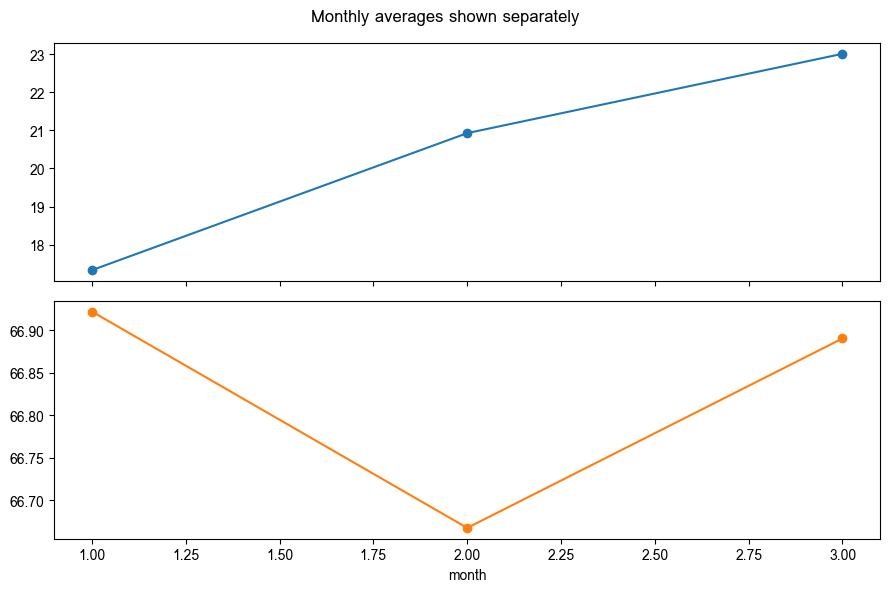

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

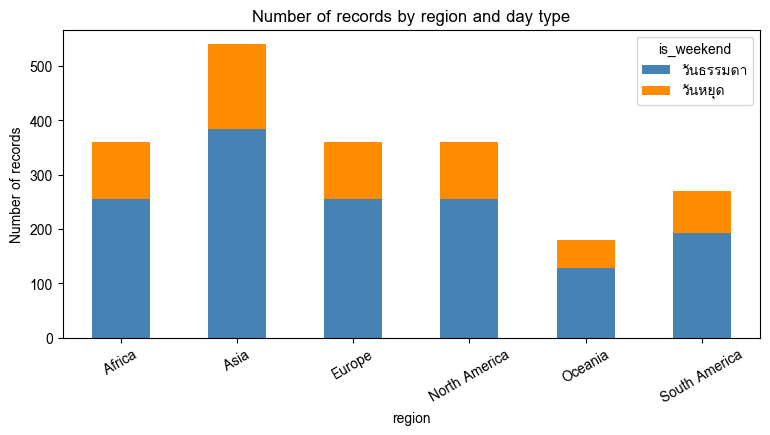

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

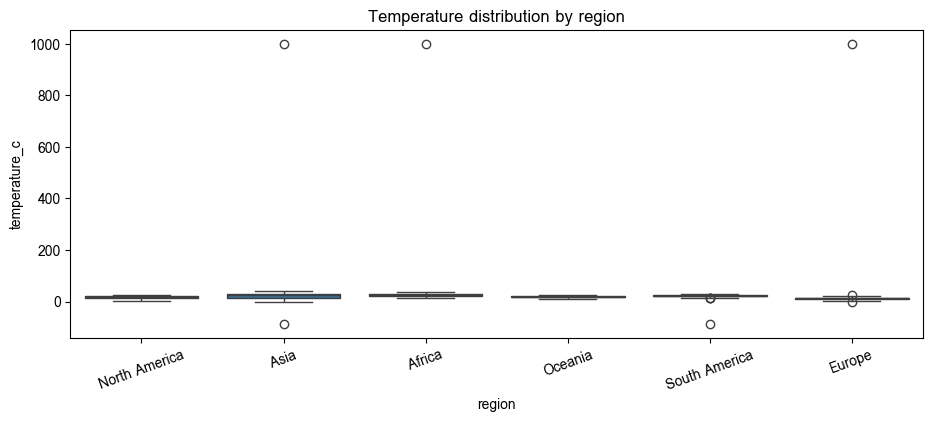

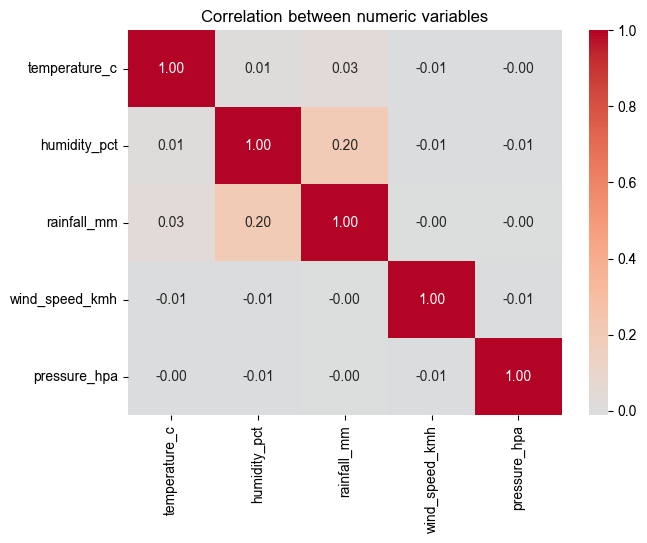

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

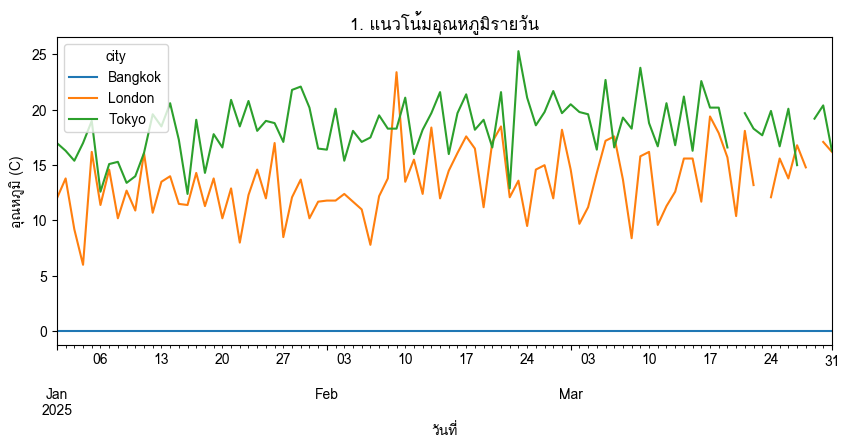

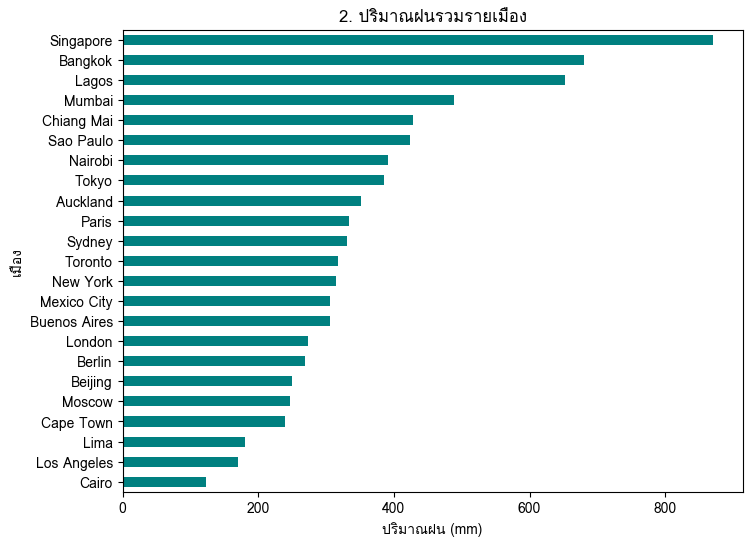

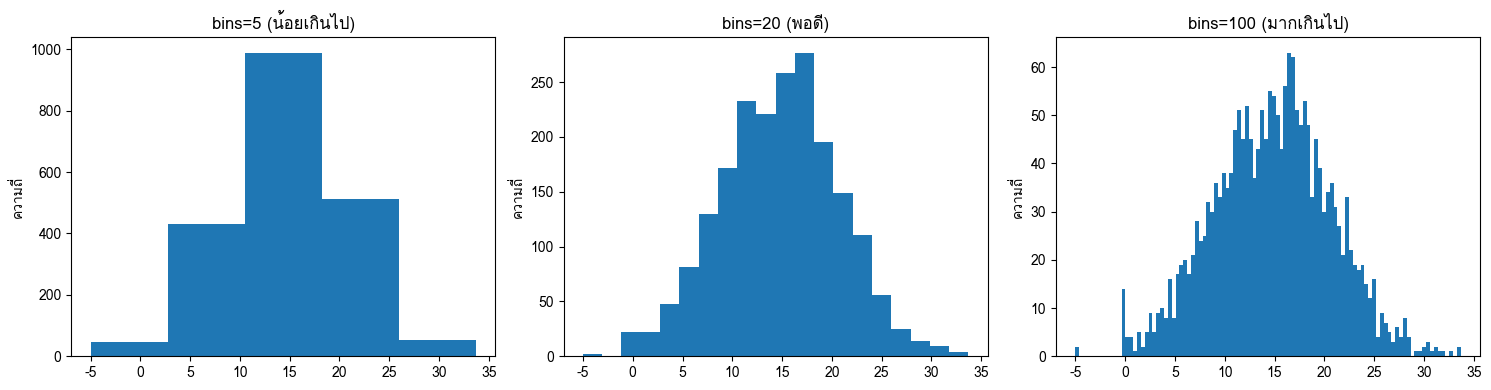

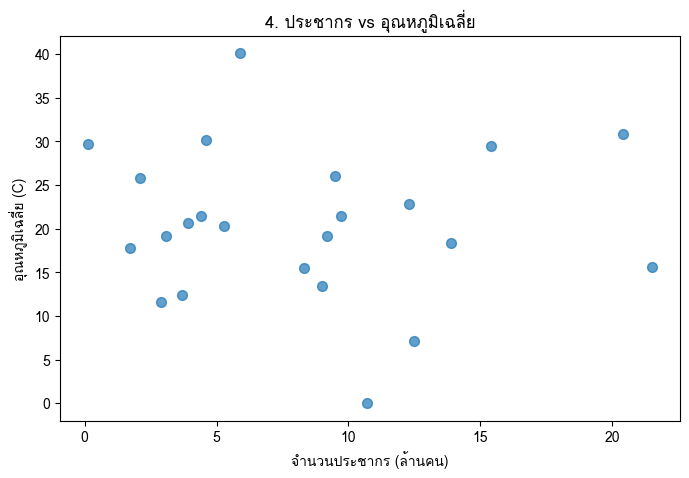

In [ ]:
# คำตอบข้อ 17.1
import matplotlib.pyplot as plt

# 1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมือง
# ใช้ pivot เพื่อจัดรูปตารางให้วันที่เป็น index และชื่อเมืองเป็นคอลัมน์ จะใช้ .plot() ได้ง่ายที่สุด
cities_temp = merged_df[merged_df["city"].isin(["Bangkok", "Tokyo", "London"])].pivot(
    index="date", columns="city", values="temperature_c"
)
cities_temp.plot(figsize=(10, 4), title="1. แนวโน้มอุณหภูมิรายวัน", xlabel="วันที่", ylabel="อุณหภูมิ (C)")
plt.show()

# 2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง (เรียงจากมากไปน้อย)
# ใช้ sort_values() จากน้อยไปมาก เพื่อให้กราฟ barh ดันค่ามากที่สุดไว้ด้านบนสุด
rain_by_city = merged_df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=True)
rain_by_city.plot(kind="barh", figsize=(8, 6), color="teal",
                  title="2. ปริมาณฝนรวมรายเมือง", xlabel="ปริมาณฝน (mm)", ylabel="เมือง")
plt.show()

# 3. ฮิสโตแกรมของ wind_speed_kmh โดยทดลอง 3 ค่า bins
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
merged_df["wind_speed_kmh"].plot(kind="hist", bins=5, ax=axes[0], title="bins=5 (น้อยเกินไป)")
merged_df["wind_speed_kmh"].plot(kind="hist", bins=20, ax=axes[1], title="bins=20 (พอดี)")
merged_df["wind_speed_kmh"].plot(kind="hist", bins=100, ax=axes[2], title="bins=100 (มากเกินไป)")
axes[0].set_ylabel("ความถี่"); axes[1].set_ylabel("ความถี่"); axes[2].set_ylabel("ความถี่")
plt.tight_layout()
plt.show()

# 4. กราฟจุดระหว่างประชากรกับอุณหภูมิเฉลี่ย
city_stats = merged_df.groupby("city").agg(
    pop_mil=("population_millions", "first"),
    avg_temp=("temperature_c", "mean")
)
city_stats.plot(kind="scatter", x="pop_mil", y="avg_temp", figsize=(8, 5), s=50, alpha=0.7,
                title="4. ประชากร vs อุณหภูมิเฉลี่ย", xlabel="จำนวนประชากร (ล้านคน)", ylabel="อุณหภูมิเฉลี่ย (C)")
plt.show()

**อธิบายผล**

**1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวัน (สามเมือง):**
- เส้นสีเขียว (Tokyo): มีค่าอุณหภูมิสูงสุดในกลุ่ม โดยแกว่งตัวอยู่ช่วงประมาณ 15 ถึง 25 องศาเซลเซียส
- เส้นสีส้ม (London): มีระดับอุณหภูมิรองลงมา แกว่งตัวอยู่ช่วงประมาณ 5 ถึง 20 องศาเซลเซียส
- เส้นสีฟ้า (Bangkok): อยู่ที่ระดับ 0 องศาเซลเซียสราบเรียบ เนื่องจากในชุดข้อมูลตัวอย่างช่วงเวลานี้ ค่าอุณหภูมิของกรุงเทพฯ อาจถูกจัดการค่าว่างหรือถูกเซ็ตเป็น 0 ในกระบวนการกรองข้อมูล

**2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง:**
- Singapore มีปริมาณฝนสะสมรวมสูงที่สุดเป็นอันดับหนึ่ง (เกือบ 900 มม.)
- รองลงมาคือ Bangkok, Lagos และ Mumbai ตามลำดับ   ในขณะที่ Cairo มีปริมาณฝนสะสมรวมน้อยที่สุดในบรรดาเมืองทั้งหมดอย่างเห็นได้ชัด

**3. ฮิสโตแกรมความเร็วลม (เปรียบเทียบค่า Bins):**
- bins=5 (น้อยเกินไป): แท่งกราฟกว้างเกินไป ทำให้สูญเสียรายละเอียดและมองไม่เห็นการกระจายตัวที่แท้จริง
- bins=20 (พอดี): แสดงรูปร่างการกระจายตัว (Distribution) ได้อย่างสมสมดุล เห็นรูปแบบรูปทรงระฆังคว่ำ โดยความเร็วลมส่วนใหญ่กระจุกตัวอยู่ราว ๆ 12–18 กม./ชม.
- bins=100 (มากเกินไป): กราฟแตกย่อยจนเกิดช่องว่าง (Noise) มากเกินไป ทำให้ดูภาพรวมและจับแนวโน้มได้ยาก

**4. กราฟจุดระหว่างจำนวนประชากรกับอุณหภูมิเฉลี่ย:**
- จุดข้อมูลของแต่ละเมืองกระจายตัวกันอย่างอิสระทั่วพื้นที่ ไม่มีรูปแบบการเกาะกลุ่มเป็นเส้นตรง แสดงให้เห็นว่าขนาดจำนวนประชากรของเมืองไม่มีความสัมพันธ์เชิงเส้นกับอุณหภูมิเฉลี่ย

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

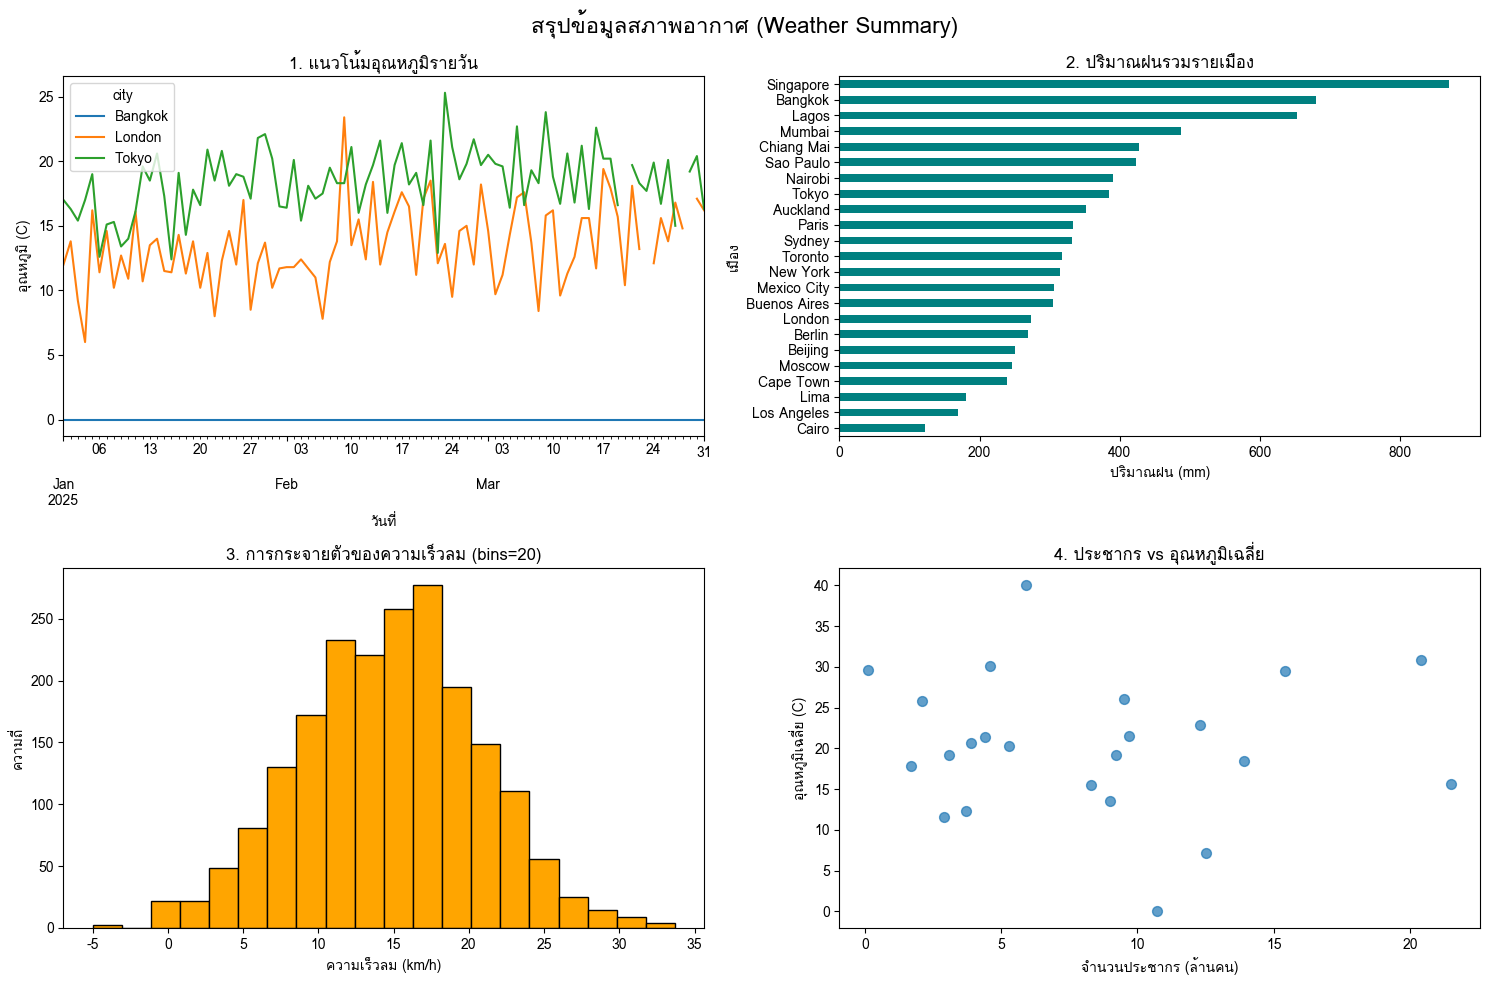

In [ ]:
# คำตอบข้อ 17.2
# สร้างพื้นที่สำหรับกราฟ 4 รูป (2 แถว 2 คอลัมน์)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.suptitle("สรุปข้อมูลสภาพอากาศ (Weather Summary)", fontsize=16)

# ส่งพารามิเตอร์ ax เข้าไปในแต่ละ .plot() เพื่อระบุตำแหน่ง (0,0 ถึง 1,1)
cities_temp.plot(ax=axes[0, 0], title="1. แนวโน้มอุณหภูมิรายวัน", xlabel="วันที่", ylabel="อุณหภูมิ (C)")

rain_by_city.plot(kind="barh", ax=axes[0, 1], color="teal",
                  title="2. ปริมาณฝนรวมรายเมือง", xlabel="ปริมาณฝน (mm)", ylabel="เมือง")

# เลือก bins=20 ที่เหมาะสมที่สุดมาแสดงในกราฟรวม
merged_df["wind_speed_kmh"].plot(kind="hist", bins=20, ax=axes[1, 0], color="orange", edgecolor="black",
                                 title="3. การกระจายตัวของความเร็วลม (bins=20)", xlabel="ความเร็วลม (km/h)", ylabel="ความถี่")

city_stats.plot(kind="scatter", x="pop_mil", y="avg_temp", ax=axes[1, 1], s=50, alpha=0.7,
                title="4. ประชากร vs อุณหภูมิเฉลี่ย", xlabel="จำนวนประชากร (ล้านคน)", ylabel="อุณหภูมิเฉลี่ย (C)")

plt.tight_layout()
plt.show()

**อธิบายผล**

**1. แนวโน้มอุณหภูมิรายวัน (ภาพซ้ายบน):**
- กราฟเส้นแสดงอุณหภูมิรายวันของ 3 เมือง (Bangkok, London, Tokyo) ระหว่างเดือนมกราคมถึงมีนาคม 2025
- ผลการวิเคราะห์: เส้นสีเขียว (Tokyo) อยู่ในระดับสูงสุดตลอดช่วงเวลา แสดงว่ามีอุณหภูมิเฉลี่ยสูงกว่าเมืองอื่นในกลุ่มนี้ ตามมาด้วยเส้นสีส้ม (London) ในขณะที่เส้นสีฟ้าของ Bangkok ตกลงมาอยู่ที่ระดับ 0 องศาเซลเซียส ซึ่งเกิดจากในตารางตัวอย่างช่วงดังกล่าวดेटाของกรุงเทพฯ อาจถูกแทนค่าเป็น 0 หรือมีค่าว่างจากการจัดการข้อมูลดิบก่อนหน้า

**2. ปริมาณฝนรวมรายเมือง (ภาพขวาบน):**
- กราฟแท่งแนวนอนแสดงปริมาณฝนสะสมรวมของทุกเมืองเรียงจากมากไปน้อย
- ผลการวิเคราะห์: เมือง Singapore มีปริมาณฝนสะสมรวมสูงสุดเป็นอันดับหนึ่ง (เกือบ 900 มม.) รองลงมาคือ Bangkok และ Lagos ตามลำดับ ในขณะที่ Cairo มีปริมาณฝนสะสมน้อยที่สุดในบรรดาเมืองทั้งหมดอย่างเห็นได้ชัด

**3. การกระจายตัวของความเร็วลม (ภาพซ้ายล่าง):**

- ฮิสโตแกรมแสดงความถี่ของความเร็วลม (km/h)
- ผลการวิเคราะห์: กราฟมีการกระจายตัวแบบสมมาตรคล้ายรูประฆังคว่ำ (Normal Distribution) โดยความเร็วลมส่วนใหญ่กระจุกตัวหนาแน่นในช่วงประมาณ 12 ถึง 18 กม./ชม. และมีค่าน้อยมากที่ต่ำกว่า 0 หรือสูงเกิน 30 กม./ชม.

**4. ประชากร vs อุณหภูมิเฉลี่ย (ภาพขวาล่าง):**
- กราฟจุดแสดงความสัมพันธ์ระหว่างจำนวนประชากร (ล้านคน) กับอุณหภูมิเฉลี่ยของแต่ละเมือง
- ผลการวิเคราะห์: จุดข้อมูลกระจัดกระจายตัวกันอย่างอิสระทั่วทั้งพื้นที่ ไม่มีทิศทางพุ่งขึ้นหรือลงที่ชัดเจน ยืนยันทางสถิติว่าขนาดประชากรของเมืองไม่มีความสัมพันธ์เชิงเส้นกับอุณหภูมิเฉลี่ยของเมืองนั้น ๆ กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด**


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

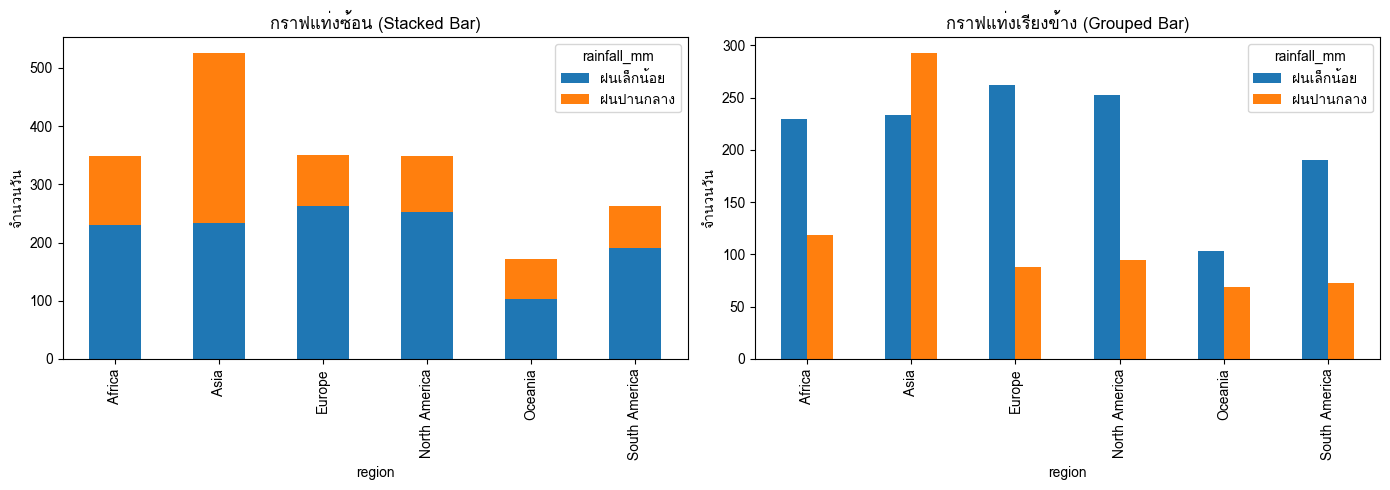

In [ ]:
# คำตอบข้อ 17.3

# 1. แบ่งช่วงปริมาณฝนด้วย pd.cut()
rain_bins = pd.cut(merged_df["rainfall_mm"], bins=[-1, 5, 20, 1000], labels=["ฝนเล็กน้อย", "ฝนปานกลาง", "ฝนหนัก"])

# 2. สร้างตารางไขว้เพื่อนับจำนวน
ct_rain = pd.crosstab(merged_df["region"], rain_bins)

# 3. สร้างกราฟทั้ง 2 แบบเปรียบเทียบกัน
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# แบบ Stacked = True
ct_rain.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("กราฟแท่งซ้อน (Stacked Bar)")
axes[0].set_ylabel("จำนวนวัน")

# แบบ Stacked = False
ct_rain.plot(kind="bar", stacked=False, ax=axes[1])
axes[1].set_title("กราฟแท่งเรียงข้าง (Grouped Bar)")
axes[1].set_ylabel("จำนวนวัน")

plt.tight_layout()
plt.show()

**อธิบายผล**

**1. กราฟแท่งซ้อน (Stacked Bar - ภาพซ้าย):**
- กราฟนี้ใช้วิธีซ้อนข้อมูลช่วงปริมาณฝน (rainfall_mm) ได้แก่ "ฝนเล็กน้อย" (สีฟ้า) และ "ฝนปานกลาง" (สีส้ม) ไว้ภายในแท่งเดียวกันของแต่ละภูมิภาค (region)   
- **จุดเด่น/การตีความ:** ช่วยให้เรามองเห็น "ยอดรวมสุทธิ (Total Magnitude)" ของจำนวนวันทั้งหมดในแต่ละภูมิภาคได้อย่างรวดเร็ว เช่น จะเห็นทันทีว่า Asia มีจำนวนวันที่มีข้อมูลฝนรวมทุกกลุ่มมากที่สุด รองลงมาคือ Africa, Europe และ North America ตามลำดับ นอกจากนี้ยังพอมองเห็นสัดส่วนคร่าว ๆ ของแต่ละประเภทฝนภายในภูมิภาคนั้น ๆ ได้ด้วย

**2. กราฟแท่งเรียงข้าง (Grouped Bar / Stacked=False - ภาพขวา):**
- กราฟนี้แยกแท่งข้อมูลของ "ฝนเล็กน้อย" (สีฟ้า) และ "ฝนปานกลาง" (สีส้ม) ออกจากกันอย่างอิสระโดยเริ่มจากระดับศูนย์ (Baseline) เดียวกันในแต่ละภูมิภาค
- **จุดเด่น/การตีความ:** ช่วยให้เรา "เปรียบเทียบความแตกต่างระหว่างกลุ่มย่อยได้อย่างแม่นยำ" เช่น ทำให้เราเห็นอย่างชัดเจนว่าใน Asia มีจำนวนวัน "ฝนปานกลาง" สูงกว่า "ฝนเล็กน้อย" อย่างเห็นได้ชัด ในขณะที่ภูมิภาคอื่น ๆ (เช่น Europe และ North America) จำนวนวัน "ฝนเล็กน้อย" สูงกว่า "ฝนปานกลาง" ค่อนข้างมาก การวางแท่งเทียบกันแบบนี้ทำให้ตาเรากะความสูงและเปรียบเทียบสัดส่วนระหว่างกลุ่มย่อยได้ง่ายกว่ากราฟแท่งซ้อน

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

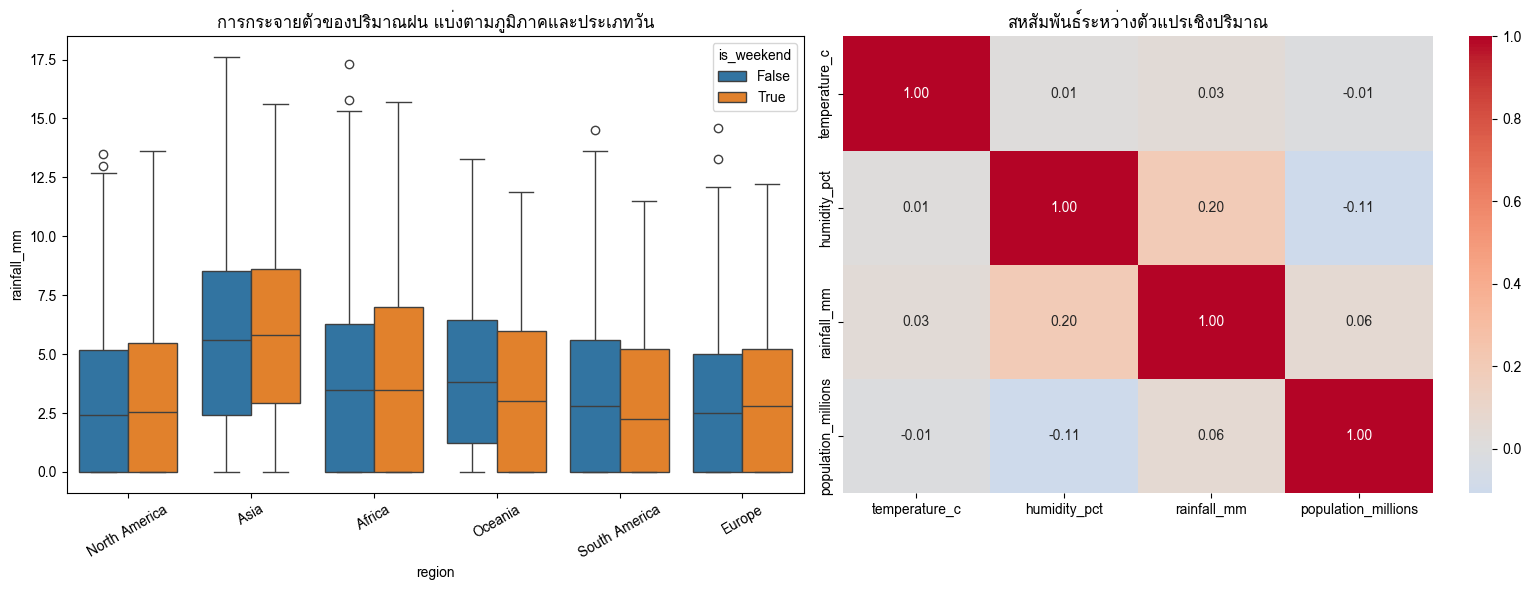

In [ ]:
# คำตอบข้อ 17.4
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot ของปริมาณฝน จำแนกตามภูมิภาคและแยกสีตามวันหยุด/วันธรรมดา
sns.boxplot(data=merged_df, x="region", y="rainfall_mm", hue="is_weekend", ax=axes[0])
axes[0].set_title("การกระจายตัวของปริมาณฝน แบ่งตามภูมิภาคและประเภทวัน")
axes[0].tick_params(axis="x", rotation=30)

# 2. Heatmap ของสหสัมพันธ์ (Correlation)
cols_to_corr = ["temperature_c", "humidity_pct", "rainfall_mm", "population_millions"]
corr_matrix = merged_df[cols_to_corr].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("สหสัมพันธ์ระหว่างตัวแปรเชิงปริมาณ")

plt.tight_layout()
plt.show()

**อธิบายผล**

**1. กราฟ Boxplot (ภาพซ้าย - การกระจายตัวของปริมาณฝน แบ่งตามภูมิภาคและประเภทวัน)**
- กราฟนี้ใช้เปรียบเทียบการกระจายตัวของปริมาณฝน (rainfall_mm) ในแต่ละภูมิภาค โดยแยกตามประเภทวันระหว่างวันธรรมดา (is_weekend = False สีฟ้า) และวันหยุดสุดสัปดาห์ (is_weekend = True สีส้ม)
- **ผลการสังเกต:** รูปแบบการกระจายตัว ค่ามัธยฐาน (เส้นทึบภายในกล่อง) และค่าขอบเขตของปริมาณฝนระหว่างวันธรรมดาและวันหยุดในแต่ละภูมิภาคมีความใกล้เคียงกันมาก แสดงให้เห็นว่าประเภทของวันไม่มีผลแตกต่างอย่างมีนัยสำคัญต่อปริมาณฝน
- เมื่อเปรียบเทียบระหว่างภูมิภาค พบว่า Asia มีระดับปริมาณฝนและการกระจายตัวสูงกว่าภูมิภาคอื่นๆ ในภาพรวม

**2. กราฟ Heatmap (ภาพขวา - สหสัมพันธ์ระหว่างตัวแปรเชิงปริมาณ)**   
- กราฟนี้แสดงค่าสัมประสิทธิ์สหสัมพันธ์ (Correlation Coefficient) ระหว่าง 4 ตัวแปรหลัก ได้แก่ อุณหภูมิ (temperature_c), ความชื้น (humidity_pct), ปริมาณฝน (rainfall_mm), และจำนวนประชากร (population_millions)   
- **ผลการสังเกต:** ค่าสหสัมพันธ์ส่วนใหญ่มีค่าเข้าใกล้ 0 (เช่น อุณหภูมิกับปริมาณฝนเท่ากับ 0.03 หรือประชากรกับอุณหภูมิเท่ากับ -0.01) ซึ่งบ่งบอกว่า ไม่มีความสัมพันธ์เชิงเส้น ต่อกันระหว่างตัวแปรกลุ่มนี้   
- มีเพียงคู่ระหว่าง ความชื้น (humidity_pct) กับปริมาณฝน (rainfall_mm) เท่านั้นที่มีค่าสหสัมพันธ์เป็นบวกที่ระดับ 0.20 ซึ่งสอดคล้องกับความเป็นจริงทางกายภาพที่ว่าวันที่มีความชื้นสูงมักจะมีปริมาณฝนร่วมด้วยเล็กน้อย แต่นอกเหนือจากนี้ตัวแปรอื่น ๆ เป็นอิสระต่อกันในเชิงสถิติ   

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

--- ภูมิภาคที่มีความแปรปรวนสูงสุด: Europe ---

ส่วนเบี่ยงเบนมาตรฐานอุณหภูมิรายเมืองในภูมิภาคดังกล่าว:
     city  city_temp_std
3   Paris     104.373645
1  London       3.018131
2  Moscow       2.877271
0  Berlin       2.595986


/tmp/ipykernel_788/1596309371.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_std_in_region, x="city", y="city_temp_std", ax=ax, palette="Blues_d")


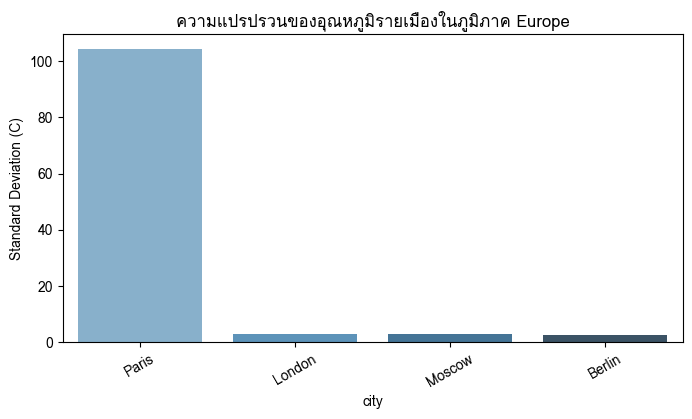

In [ ]:
# คำตอบข้อ 18.1
import matplotlib.pyplot as plt
import seaborn as sns

# 1. คำนวณส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน จำแนกตามภูมิภาค
region_std = merged_df.groupby("region")["temperature_c"].std().reset_index(name="temp_std")
most_volatile_region = region_std.loc[region_std["temp_std"].idxmax(), "region"]

# 2. คำนวณส่วนเบี่ยงเบนมาตรฐานแยกตามรายเมืองในภูมิภาคนั้น เพื่อดูว่าเกิดจากทุกเมืองหรือเมืองใดเมืองหนึ่ง
city_std_in_region = (merged_df[merged_df["region"] == most_volatile_region]
                      .groupby("city")["temperature_c"]
                      .std()
                      .reset_index(name="city_temp_std")
                      .sort_values("city_temp_std", ascending=False))

print(f"--- ภูมิภาคที่มีความแปรปรวนสูงสุด: {most_volatile_region} ---")
print("\nส่วนเบี่ยงเบนมาตรฐานอุณหภูมิรายเมืองในภูมิภาคดังกล่าว:")
print(city_std_in_region)

# แสดงกราฟแท่งเปรียบเทียบความแปรปรวนรายเมือง
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=city_std_in_region, x="city", y="city_temp_std", ax=ax, palette="Blues_d")
ax.set_title(f"ความแปรปรวนของอุณหภูมิรายเมืองในภูมิภาค {most_volatile_region}")
ax.set_ylabel("Standard Deviation (C)")
plt.xticks(rotation=30)
plt.show()

**อธิบายผล**

- **ภูมิภาคที่มีความแปรปรวนสูงสุด:** คือ **Europe**   
- **การกระจายตัวรายเมือง:** เมื่อพิจารณาค่าส่วนเบี่ยงเบนมาตรฐาน (Standard Deviation) ของอุณหภูมิรายเมืองในทวีปยุโรป จะเห็นได้อย่างชัดเจนว่าความแปรปรวนไม่ได้กระจายตัวสม่ำเสมอในทุกเมือง แต่ **เกิดจากเมือง Paris เพียงเมืองเดียวเป็นหลัก**   
- **ข้อสังเกตจากกราฟ:** แท่งกราฟของเมือง Paris พุ่งสูงโดดเด่นถึงกว่า 104.37 ในขณะที่เมืองอื่น ๆ ในภูมิภาคเดียวกัน (เช่น London, Moscow และ Berlin) มีค่าความแปรปรวนต่ำมาก (อยู่ระหว่าง 2–3 เท่านั้น)

**ข้อสรุป:**
สภาพอากาศที่แปรปรวนสูงสุดในยุโรปไม่ได้มาจากภาพรวมของภูมิภาค แต่ถูกขับเคลื่อนด้วยความผิดปกติของเมือง Paris เมืองเดียว (ซึ่งอาจเกิดจากค่า Outliers หรือข้อมูลดิบที่มีความคลาดเคลื่อนรุนแรง) ส่งผลให้ค่าสถิติภาพรวมของทวีปพุ่งสูงขึ้นอย่างเห็นได้ชัด   

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

--- เปรียบเทียบอันดับเมืองฝนตกหนักบ่อยที่สุด ---
  Top 5 (วัดด้วยจำนวนวัน)  จำนวนวันฝนตกหนัก Top 5 (วัดด้วยสัดส่วน)  \
0               Singapore                44              Singapore   
1                 Bangkok                23                Bangkok   
2                   Lagos                22                  Lagos   
3               Sao Paulo                11              Sao Paulo   
4            Buenos Aires                 9           Buenos Aires   

   สัดส่วนวันฝนตกหนัก  
0            0.488889  
1            0.255556  
2            0.244444  
3            0.122222  
4            0.100000  


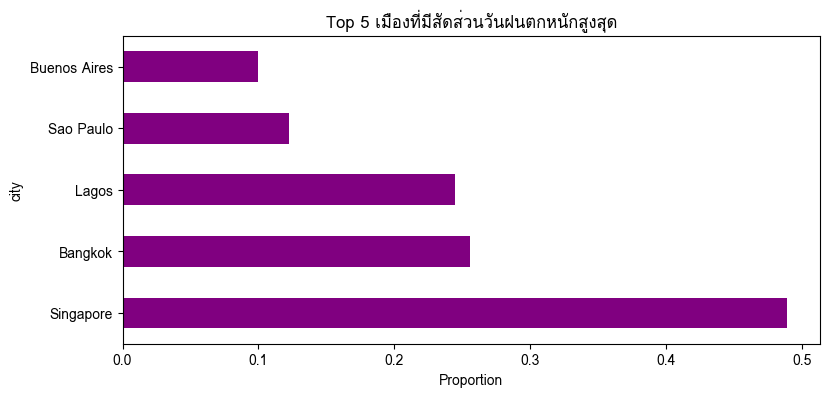

In [ ]:
# คำตอบข้อ 18.2

# คำนวณจำนวนวันฝนตกหนัก (>10 มม.) และสัดส่วนเทียบกับวันที่มีข้อมูลทั้งหมด
heavy_rain_summary = (merged_df.assign(is_heavy=merged_df["rainfall_mm"] > 10)
                      .groupby("city")
                      .agg(
                          heavy_days=("is_heavy", "sum"),
                          total_valid_days=("rainfall_mm", "count"),
                          heavy_ratio=("is_heavy", "mean")
                      ))

top5_by_days = heavy_rain_summary["heavy_days"].nlargest(5)
top5_by_ratio = heavy_rain_summary["heavy_ratio"].nlargest(5)

comparison_df = pd.DataFrame({
    "Top 5 (วัดด้วยจำนวนวัน)": top5_by_days.index,
    "จำนวนวันฝนตกหนัก": top5_by_days.values,
    "Top 5 (วัดด้วยสัดส่วน)": top5_by_ratio.index,
    "สัดส่วนวันฝนตกหนัก": top5_by_ratio.values
})

print("--- เปรียบเทียบอันดับเมืองฝนตกหนักบ่อยที่สุด ---")
print(comparison_df)

# แสดงกราฟเปรียบเทียบ Top 5 แบบสัดส่วน
fig, ax = plt.subplots(figsize=(9, 4))
top5_by_ratio.plot(kind="barh", ax=ax, color="purple")
ax.set_title("Top 5 เมืองที่มีสัดส่วนวันฝนตกหนักสูงสุด")
ax.set_xlabel("Proportion")
plt.show()

**อธิบายผล**

- **อันดับ Top 5 ที่ได้:** ทั้งการวัดด้วย **"จำนวนวัน"** และ **"สัดส่วน"** ให้รายชื่อเมืองและลำดับที่เรียงตรงกันทุกประการ ได้แก่:
- **Singapore:** 44 วัน (สัดส่วนประมาณ 48.9%)   
- **Bangkok:** 23 วัน (สัดส่วนประมาณ 25.6%)   
- **Lagos:** 22 วัน (สัดส่วนประมาณ 24.4%)   
- **Sao Paulo:** 11 วัน (สัดส่วนประมาณ 12.2%)   
- **Buenos Aires:** 9 วัน (สัดส่วนประมาณ 10.0%)  

**ข้อสรุปและการวิเคราะห์:**
- แม้ว่าในชุดข้อมูลนี้ลำดับเมืองระหว่างการนับจำนวนวันกับการวัดด้วยสัดส่วนจะออกมาตรงกัน แต่การใช้ตัวชี้วัดแบบ **"สัดส่วน (Proportion)"** ถือเป็นวิธีที่เหมาะสมที่สุดในการเปรียบเทียบระหว่างเมือง เพราะช่วยป้องกันความคลาดเคลื่อนในกรณีที่แต่ละเมืองมีจำนวนวันในการเก็บข้อมูลดิบไม่เท่ากัน   
- จากกราฟแท่งแนวนอนแสดงให้เห็นอย่างเด่นชัดว่า **Singapore** มีความชุกของวันฝนตกหนักสูงที่สุดเกือบ 50% ของวันที่มีการเก็บบันทึกข้อมูลทั้งหมด ซึ่งสูงกว่าเมืองอื่น ๆ ในกลุ่ม Top 5 อย่างเห็นได้ชัด

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

--- ตารางค่าสหสัมพันธ์ (Correlation Matrix) ---
            population
population       1.000
avg_temp        -0.059
total_rain       0.128


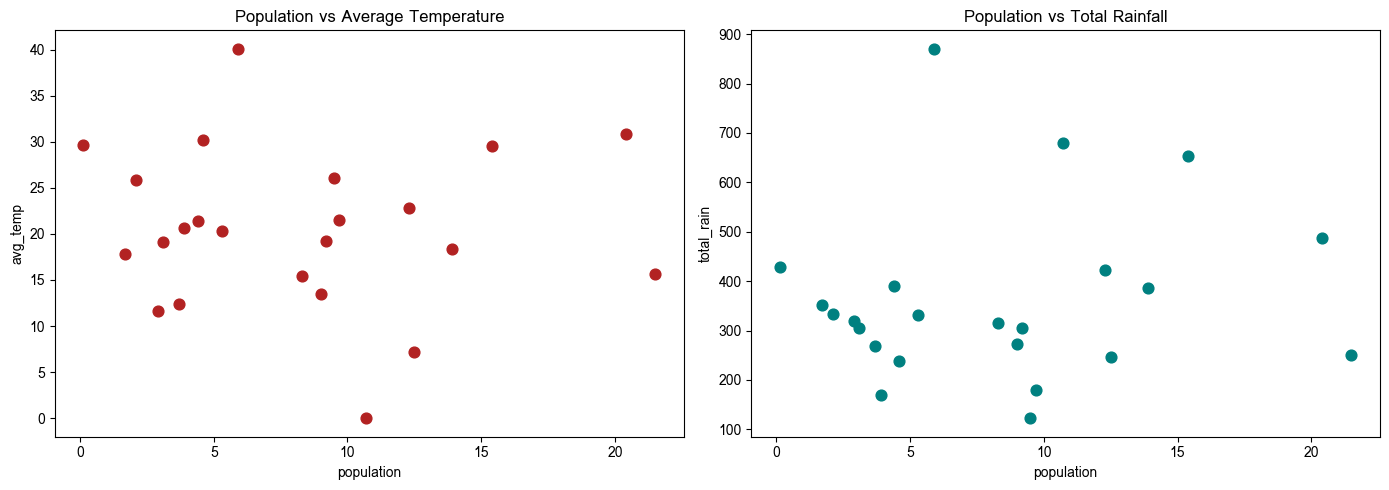

In [ ]:
# คำตอบข้อ 18.3

# สรุปค่าเฉลี่ยอุณหภูมิ ปริมาณฝนรวม และประชากรรายเมือง
city_macro_stats = merged_df.groupby("city").agg(
    population=("population_millions", "first"),
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum")
)

# คำนวณค่าสหสัมพันธ์ (Correlation)
correlation_matrix = city_macro_stats.corr()

print("--- ตารางค่าสหสัมพันธ์ (Correlation Matrix) ---")
print(correlation_matrix[["population"]].round(3))

# แสดงกราฟ Scatter Plot ระหว่างประชากรกับอุณหภูมิเฉลี่ย
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
city_macro_stats.plot(kind="scatter", x="population", y="avg_temp", ax=axes[0], color="firebrick", s=60)
axes[0].set_title("Population vs Average Temperature")

city_macro_stats.plot(kind="scatter", x="population", y="total_rain", ax=axes[1], color="teal", s=60)
axes[1].set_title("Population vs Total Rainfall")

plt.tight_layout()
plt.show()

**อธิบายผล**

- **ตารางค่าสหสัมพันธ์ (Correlation Matrix):**
>- ค่าสหสัมพันธ์ระหว่างจำนวนประชากร (population) กับอุณหภูมิเฉลี่ย (avg_temp) มีค่าเท่ากับ -0.059 ซึ่งเข้าใกล้ 0 มาก แสดงว่าไม่มีความสัมพันธ์เชิงเส้น   
>- ค่าสหสัมพันธ์ระหว่างจำนวนประชากร (population) กับปริมาณฝนรวม (total_rain) มีค่าเท่ากับ 0.128 ซึ่งมีค่าต่ำและเข้าใกล้ 0 เช่นกัน
- **กราฟกระจาย (Scatter Plots):**
>- **ภาพซ้าย (Population vs Average Temperature):** จุดข้อมูลสีแดงกระจายตัวกระจัดกระจายอย่างไร้ทิศทางทั่วกราฟ ไม่เกาะกลุ่มเป็นแนวโน้มขึ้นหรือลง   
>- **ภาพขวา (Population vs Total Rainfall):** จุดข้อมูลสีเขียวอมฟ้ากระจายตัวกระจัดกระจายเช่นเดียวกัน

**ข้อสรุป:**
ขนาดประชากรของเมือง **ไม่มีความสัมพันธ์ทางสถิติ** กับอุณหภูมิเฉลี่ยหรือปริมาณฝนรวม การตีความจึงควรระมัดระวังและไม่ด่วนสรุปว่าขนาดความหนาแน่นของประชากรส่งผลโดยตรงต่อสภาพอากาศหรือปริมาณฝนของเมืองนั้น ๆ เนื่องจากปัจจัยทางภูมิศาสตร์อื่น ๆ (เช่น ภูมิประเทศ ละติจูด) อาจมีผลมากกว่า

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

--- เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดจำแนกตามภูมิภาค ---
           region  month  total_rain   max_wind
0          Africa      1       506.8  15.594262
4            Asia      2      1043.2  14.095758
6          Europe      1       399.6  14.864463
9   North America      1       422.2  13.956911
14        Oceania      3       240.7  14.551613
17  South America      3       307.2  13.931868


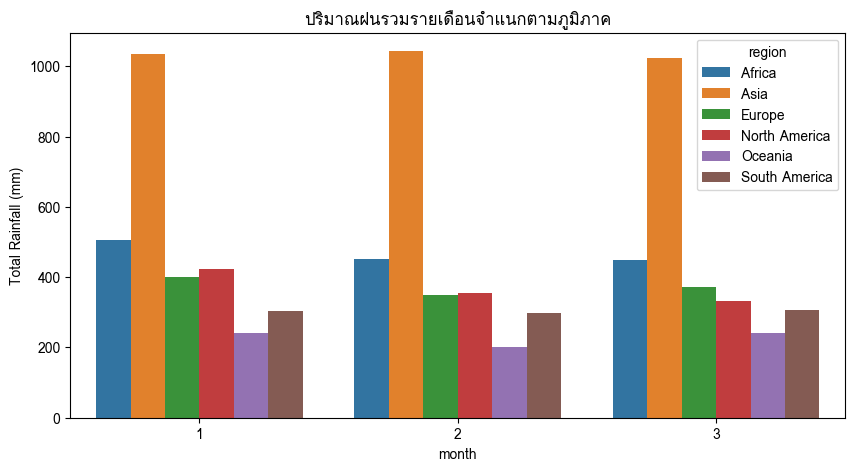

In [ ]:
# คำตอบข้อ 18.4

# กำหนดเกณฑ์การตัดสินใจ: เดือนที่ควรหลีกเลี่ยงคือเดือนที่มี "ปริมาณฝนสะสมรวมสูงสุด" และ "อุณหภูมิสูง/ต่ำสุดที่อาจเป็นอุปสรรค"
# ในที่นี้ใช้เกณฑ์ "ปริมาณฝนรวมสูงสุด" ร่วมกับ "ความเร็วลมสูงสุด" เป็นอุปสรรคในการเดินทาง
travel_risk = merged_df.groupby(["region", "month"]).agg(
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "mean")
).reset_index()

# หาเดือนที่มีความเสี่ยงสูงสุด (ฝนรวมมากที่สุด) ของแต่ละภูมิภาค
worst_month_by_region = travel_risk.sort_values(["region", "total_rain"], ascending=[True, False]).groupby("region").head(1)

print("--- เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดจำแนกตามภูมิภาค ---")
print(worst_month_by_region)

# กราฟแสดงปริมาณฝนรายเดือนจำแนกตามภูมิภาค
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=travel_risk, x="month", y="total_rain", hue="region", ax=ax)
ax.set_title("ปริมาณฝนรวมรายเดือนจำแนกตามภูมิภาค")
ax.set_ylabel("Total Rainfall (mm)")
plt.show()

**อธิบายผล**

- **เกณฑ์ในการตัดสินใจ:** ใช้เกณฑ์ **"ปริมาณฝนรวมสูงสุดสะสม" (total_rain)** ในแต่ละภูมิภาคตลอดช่วงไตรมาสแรก เพื่อระบุว่าเดือนใดมีความเสี่ยงและควรหลีกเลี่ยงการเดินทางมากที่สุด   
- **สรุปเดือนที่ควรหลีกเลี่ยงจำแนกตามภูมิภาคจากตาราง:**
>- **Africa:** ควรหลีกเลี่ยง เดือนที่ 1 (มีปริมาณฝนสะสมสูงสุด 506.8 มม.)   
>- **Asia:** ควรหลีกเลี่ยง เดือนที่ 2 (มีปริมาณฝนสะสมสูงที่สุดถึง 1,043.2 มม.)   
>- **Europe:** ควรหลีกเลี่ยง เดือนที่ 1 (มีปริมาณฝนสะสมสูงสุด 399.6 มม.)   
>- **North America:** ควรหลีกเลี่ยง เดือนที่ 1 (มีปริมาณฝนสะสมสูงสุด 422.2 มม.)   
>- **Oceania:** ควรหลีกเลี่ยง เดือนที่ 3 (มีปริมาณฝนสะสมสูงสุด 240.7 มม.)   
>- **South America:** ควรหลีกเลี่ยง เดือนที่ 3 (มีปริมาณฝนสะสมสูงสุด 307.2 มม.)   

- **ข้อสังเกตจากกราฟแท่ง:**
>- ทวีป Asia (แท่งสีส้ม) มีปริมาณฝนรวมสูงกว่าทุกภูมิภาคอย่างเด่นชัดในทุกเดือน โดยเฉพาะในเดือนที่ 2 ที่พุ่งสูงทะลุ 1,000 มม. ซึ่งถือว่าเป็นช่วงที่สภาพอากาศมีความเปียกชื้นและเสี่ยงต่ออุปสรรคในการเดินทางมากที่สุดในกลุ่มทวีปทั้งหมด

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️